In [427]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import statsmodels.api as sm
from windrose import WindroseAxes
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans

## DPW Unsupervised

In [428]:
dpw_final = pd.read_csv("final PM data/dpw_final_pm25.csv")
dpw_final.head()

,datetime_utc,rh,temp,pm25,ws,wd,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
0,2025-01-02 06:00:00+00:00,58.840000,4.361667,0.494283,9.30,270.0,9.300000,1.708382e-15,6,1.000000,6.123234e-17,0.399550,0.464817,0.442483,0.841567,0
1,2025-01-02 07:00:00+00:00,55.430000,4.113333,0.694683,5.60,260.0,5.514923,9.724298e-01,7,0.965926,-2.588190e-01,0.494283,0.399550,0.464817,0.478867,0
2,2025-01-02 08:00:00+00:00,52.586667,3.908333,0.886617,5.70,280.0,5.613404,-9.897946e-01,8,0.866025,-5.000000e-01,0.694683,0.494283,0.399550,0.458833,0
3,2025-01-02 09:00:00+00:00,50.208333,3.943333,0.952167,7.20,290.0,6.765787,-2.462545e+00,9,0.707107,-7.071068e-01,0.886617,0.694683,0.494283,0.442483,0
4,2025-01-02 10:00:00+00:00,49.291667,4.011667,0.969433,4.45,260.0,4.382395,7.727344e-01,10,0.500000,-8.660254e-01,0.952167,0.886617,0.694683,0.464817,0


In [429]:
#define features to be used in algorithm here
#initially we just use wind and PM 2.5 concentrations
X = dpw_final[["pm25", "wind_u", "wind_v"]].values

#scale all features using Z score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#use five clusters to generally align with bins
kmeans = KMeans(n_clusters=5, random_state=8)
clusters = kmeans.fit_predict(X_scaled)

dpw_final["cluster"] = clusters

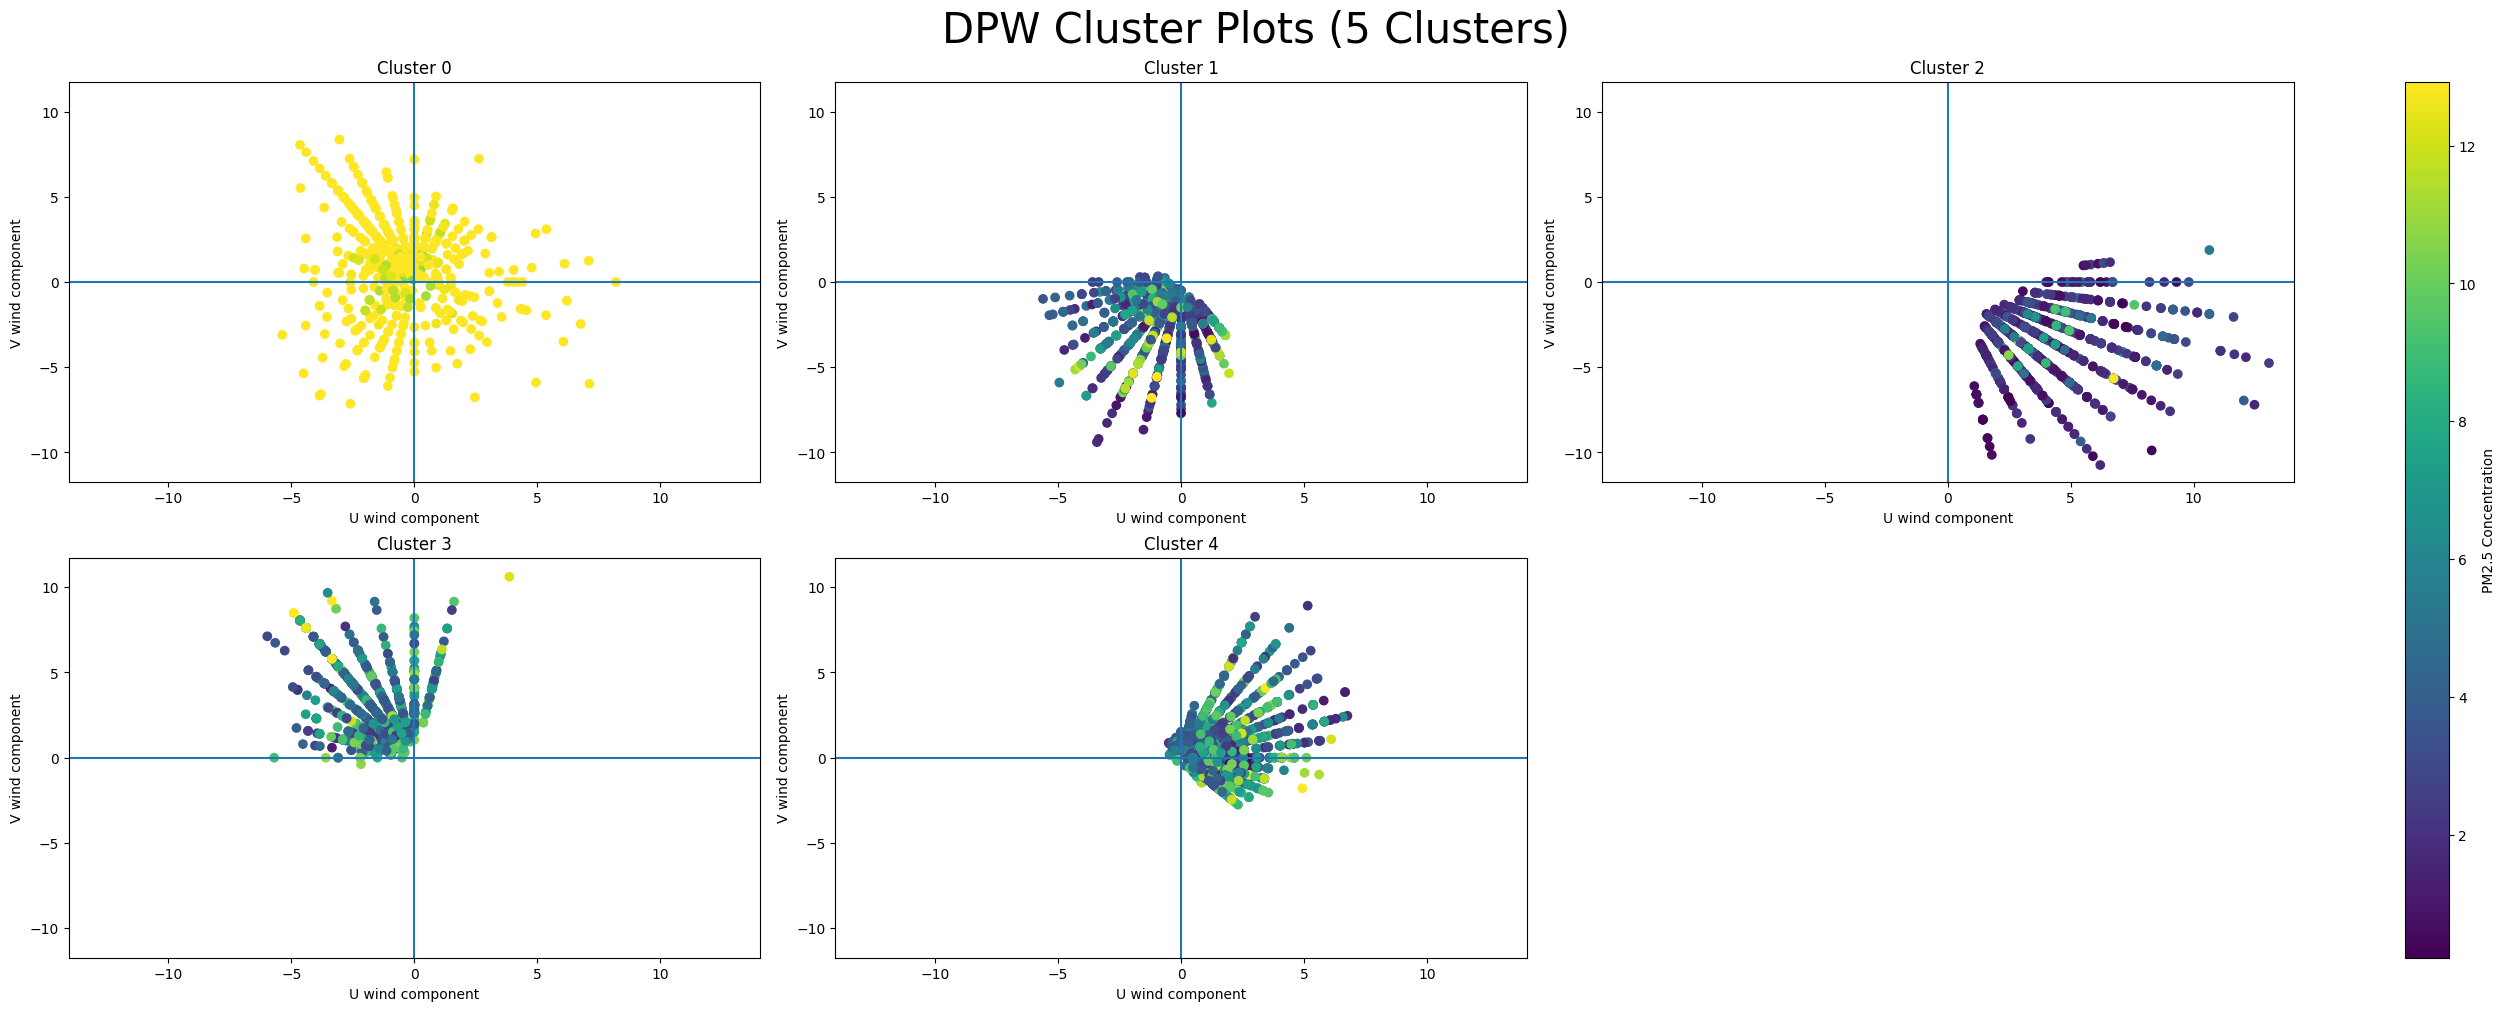

In [430]:
fig, axes = plt.subplots(2, 3, figsize=(25, 10), constrained_layout=True)
axes = axes.flatten()

#define shared color scale for comparison
#outliers make it hard to differentiate lower concentrations- utilize lower quantile
vmin = dpw_final["pm25"].min()
vmax = dpw_final["pm25"].quantile(0.9)

#bounds that will be used for all plots
u_abs = max(abs(dpw_final["wind_u"].min()), abs(dpw_final["wind_u"].max()))
v_abs = max(abs(dpw_final["wind_v"].min()), abs(dpw_final["wind_v"].max()))

clusters = sorted(dpw_final["cluster"].unique())
for i, c in enumerate(clusters):
    df_c = dpw_final[dpw_final["cluster"] == c]
    
    sc = axes[i].scatter(df_c["wind_u"], df_c["wind_v"], c=df_c["pm25"], vmin=vmin, vmax=vmax)
    
    title_string = "Cluster " + str(c)
    axes[i].set_title(title_string)
    axes[i].set_xlabel("U wind component")
    axes[i].set_ylabel("V wind component")
    
    #set axis limits
    axes[i].set_xlim(-u_abs - 1, u_abs + 1)
    axes[i].set_ylim(-v_abs - 1, v_abs + 1)
    
    #draw axis lines
    axes[i].axhline(0)
    axes[i].axvline(0)

#remove extra plot
fig.delaxes(axes[-1])

fig.colorbar(sc, ax=axes, label="PM2.5 Concentration")
fig.suptitle("DPW Cluster Plots (5 Clusters)", fontsize=30)
plt.show()

          count       mean       std        min        25%        50%        75%        max
cluster                                                                                    
0         585.0  17.294689  6.292877  10.668983  13.571083  15.295783  19.138150  66.981817
1         922.0   4.736325  2.829691   0.408117   2.718467   3.957433   6.224879  14.621483
2        1058.0   2.615807  1.811878   0.215217   1.556663   2.116900   3.181263  16.046250
3        1254.0   6.018409  2.828498   0.502833   3.787771   5.485925   8.159154  14.544767
4        1119.0   5.295100  2.853937   0.310500   3.064658   4.748050   7.324508  14.267033


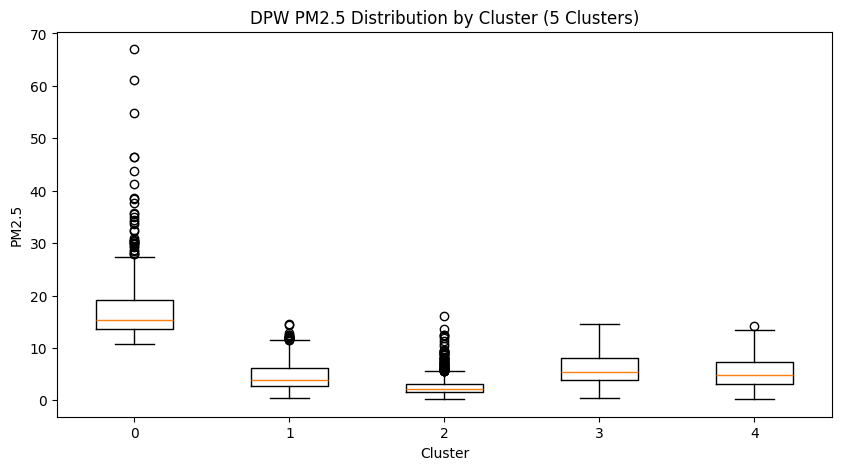

In [431]:
#print cluster statistics for PM2.5
cluster_stats = dpw_final.groupby("cluster")["pm25"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(dpw_final[dpw_final["cluster"] == c]["pm25"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("DPW PM2.5 Distribution by Cluster (5 Clusters)")
plt.xlabel("Cluster")
plt.ylabel("PM2.5")

plt.show()

          count      mean       std       min   25%    50%   75%   max
cluster                                                               
0         585.0  3.105641  1.744929  0.166667  1.70  2.650  4.10   9.3
1         922.0  3.263937  1.619877  0.433333  2.10  3.100  4.10  10.0
2        1058.0  5.724386  2.011530  2.450000  4.10  5.325  6.70  14.4
3        1254.0  3.717996  1.853693  0.500000  2.25  3.350  4.75  11.3
4        1119.0  2.769735  1.607033  0.250000  1.50  2.600  3.60  10.3


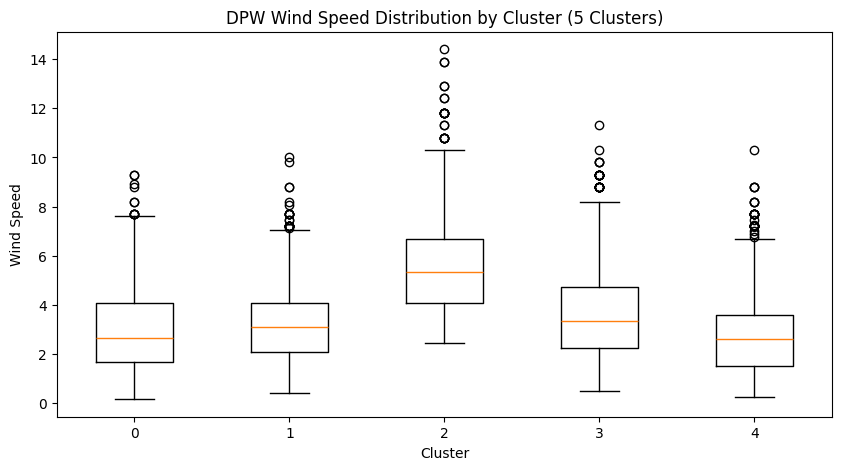

In [432]:
#print cluster statistics for wind speed
cluster_stats = dpw_final.groupby("cluster")["ws"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(dpw_final[dpw_final["cluster"] == c]["ws"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("DPW Wind Speed Distribution by Cluster (5 Clusters)")
plt.xlabel("Cluster")
plt.ylabel("Wind Speed")

plt.show()

In [433]:
# repeat experiment with 9 clusters

#define features to be used in algorithm here
#initially we just use wind and PM 2.5 concentrations
X = dpw_final[["pm25", "wind_u", "wind_v"]].values

#scale all features using Z score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#use five clusters to generally align with bins
kmeans = KMeans(n_clusters=9, random_state=8)
clusters = kmeans.fit_predict(X_scaled)

dpw_final["cluster"] = clusters

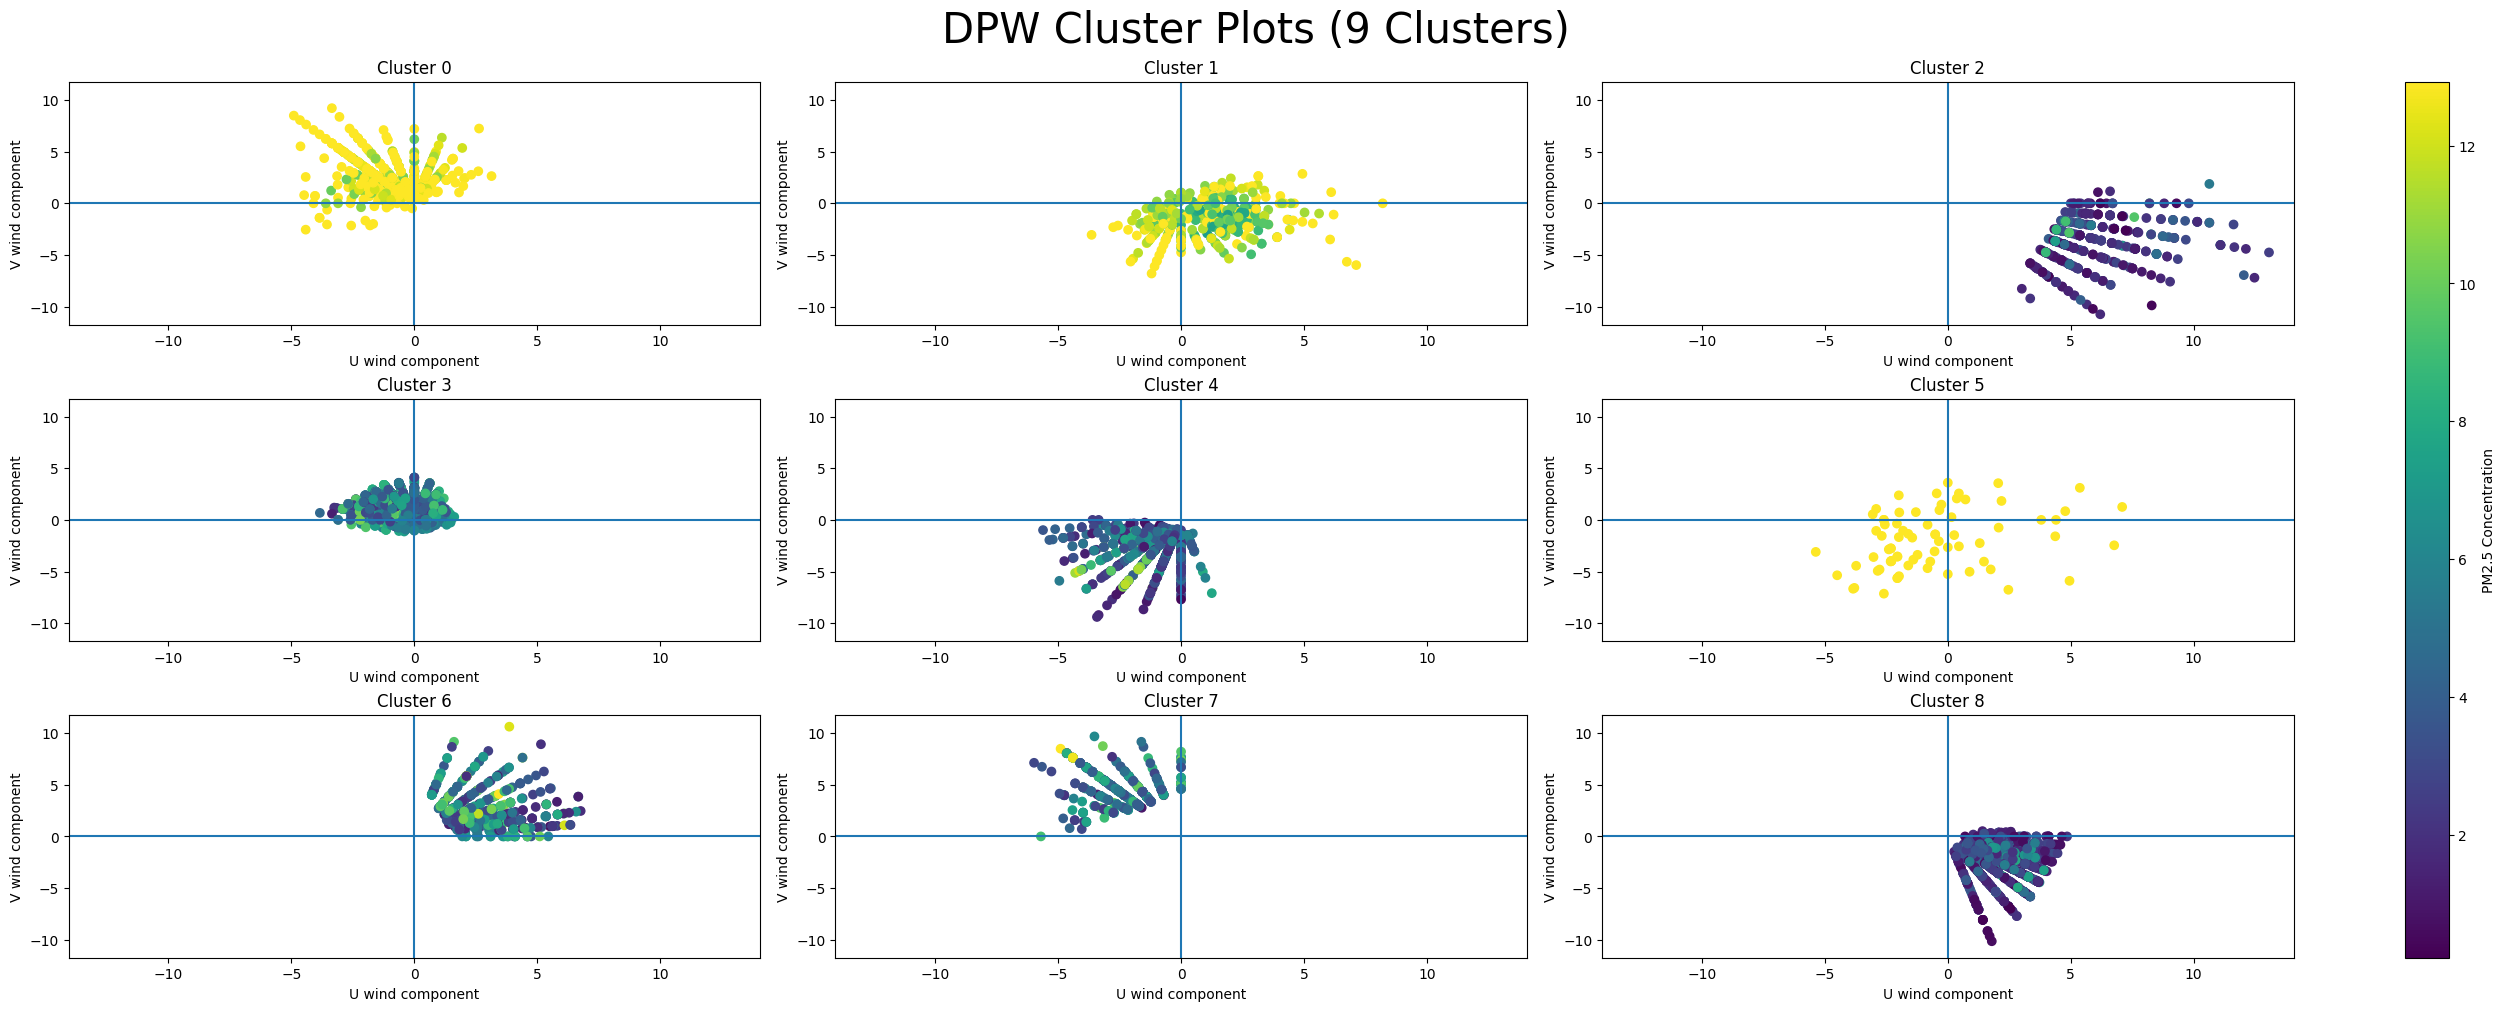

In [434]:
fig, axes = plt.subplots(3, 3, figsize=(25, 10), constrained_layout=True)
axes = axes.flatten()

#define shared color scale for comparison
#outliers make it hard to differentiate lower concentrations- utilize lower quantile
vmin = dpw_final["pm25"].min()
vmax = dpw_final["pm25"].quantile(0.9)

#bounds that will be used for all plots
u_abs = max(abs(dpw_final["wind_u"].min()), abs(dpw_final["wind_u"].max()))
v_abs = max(abs(dpw_final["wind_v"].min()), abs(dpw_final["wind_v"].max()))

clusters = sorted(dpw_final["cluster"].unique())
for i, c in enumerate(clusters):
    df_c = dpw_final[dpw_final["cluster"] == c]
    
    sc = axes[i].scatter(df_c["wind_u"], df_c["wind_v"], c=df_c["pm25"], vmin=vmin, vmax=vmax)
    
    title_string = "Cluster " + str(c)
    axes[i].set_title(title_string)
    axes[i].set_xlabel("U wind component")
    axes[i].set_ylabel("V wind component")
    
    #set axis limits
    axes[i].set_xlim(-u_abs - 1, u_abs + 1)
    axes[i].set_ylim(-v_abs - 1, v_abs + 1)
    
    #draw axis lines
    axes[i].axhline(0)
    axes[i].axvline(0)


fig.colorbar(sc, ax=axes, label="PM2.5 Concentration")
fig.suptitle("DPW Cluster Plots (9 Clusters)", fontsize=30)
plt.show()

          count       mean       std        min        25%        50%        75%        max
cluster                                                                                    
0         480.0  14.720035  3.317153   9.670417  12.047567  14.184267  16.693829  26.692600
1         367.0  11.860025  3.100641   7.211400   9.540475  11.369317  13.561933  22.166100
2         448.0   2.593823  1.592238   0.221017   1.591083   2.173300   3.371638   9.447283
3        1006.0   5.551897  2.250782   0.502833   3.852508   5.227825   7.236808  10.477583
4         645.0   4.280842  2.355346   0.408117   2.647950   3.680217   5.483550  12.157633
5          74.0  29.755710  8.654081  21.689467  24.580683  26.725075  30.906417  66.981817
6         457.0   5.254739  2.780126   0.310500   2.967717   4.995000   7.317267  13.319167
7         481.0   5.159117  2.439037   0.710733   3.339217   4.681217   6.752583  13.883017
8         980.0   2.767967  1.579664   0.215217   1.660667   2.417775   3.506500

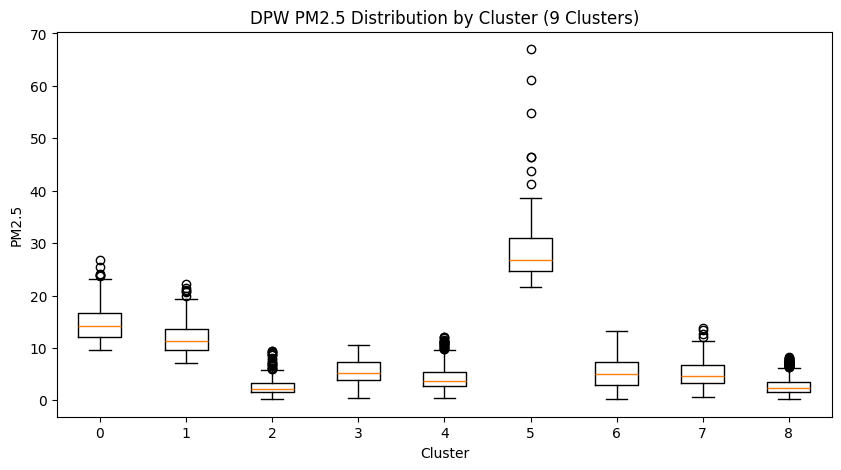

In [435]:
#print cluster statistics for PM2.5
cluster_stats = dpw_final.groupby("cluster")["pm25"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(dpw_final[dpw_final["cluster"] == c]["pm25"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("DPW PM2.5 Distribution by Cluster (9 Clusters)")
plt.xlabel("Cluster")
plt.ylabel("PM2.5")

plt.show()

          count      mean       std       min   25%       50%     75%   max
cluster                                                                    
0         480.0  3.314375  1.705825  0.450000  2.10  3.100000  4.2625   9.8
1         367.0  2.752044  1.437758  0.166667  1.50  2.600000  3.6000   9.3
2         448.0  7.332143  1.755457  4.850000  6.20  6.900000  8.2000  14.4
3        1006.0  1.953877  0.843801  0.250000  1.25  2.050000  2.6000   4.1
4         645.0  3.571214  1.621398  0.900000  2.45  3.200000  4.6000  10.0
5          74.0  3.904505  1.848810  0.300000  2.60  3.666667  5.0375   7.7
6         457.0  4.330343  1.583891  1.833333  3.10  4.100000  5.1000  11.3
7         481.0  5.329903  1.486545  3.200000  4.10  5.100000  6.2000  10.3
8         980.0  3.732585  1.467252  0.700000  2.60  3.600000  4.6000  10.3


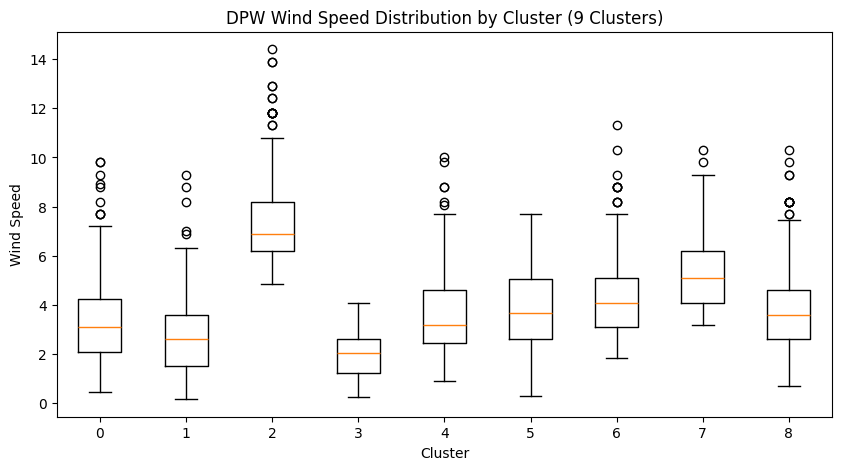

In [436]:
#print cluster statistics for wind speed
cluster_stats = dpw_final.groupby("cluster")["ws"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(dpw_final[dpw_final["cluster"] == c]["ws"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("DPW Wind Speed Distribution by Cluster (9 Clusters)")
plt.xlabel("Cluster")
plt.ylabel("Wind Speed")

plt.show()

In [437]:
#repeat experiment with 5 clusters, but now including humidity

#define features to be used in algorithm here
#initially we just use wind and PM 2.5 concentrations
X = dpw_final[["pm25", "wind_u", "wind_v", "rh"]].values

#scale all features using Z score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#use five clusters to generally align with bins
kmeans = KMeans(n_clusters=9, random_state=8)
clusters = kmeans.fit_predict(X_scaled)

dpw_final["cluster"] = clusters

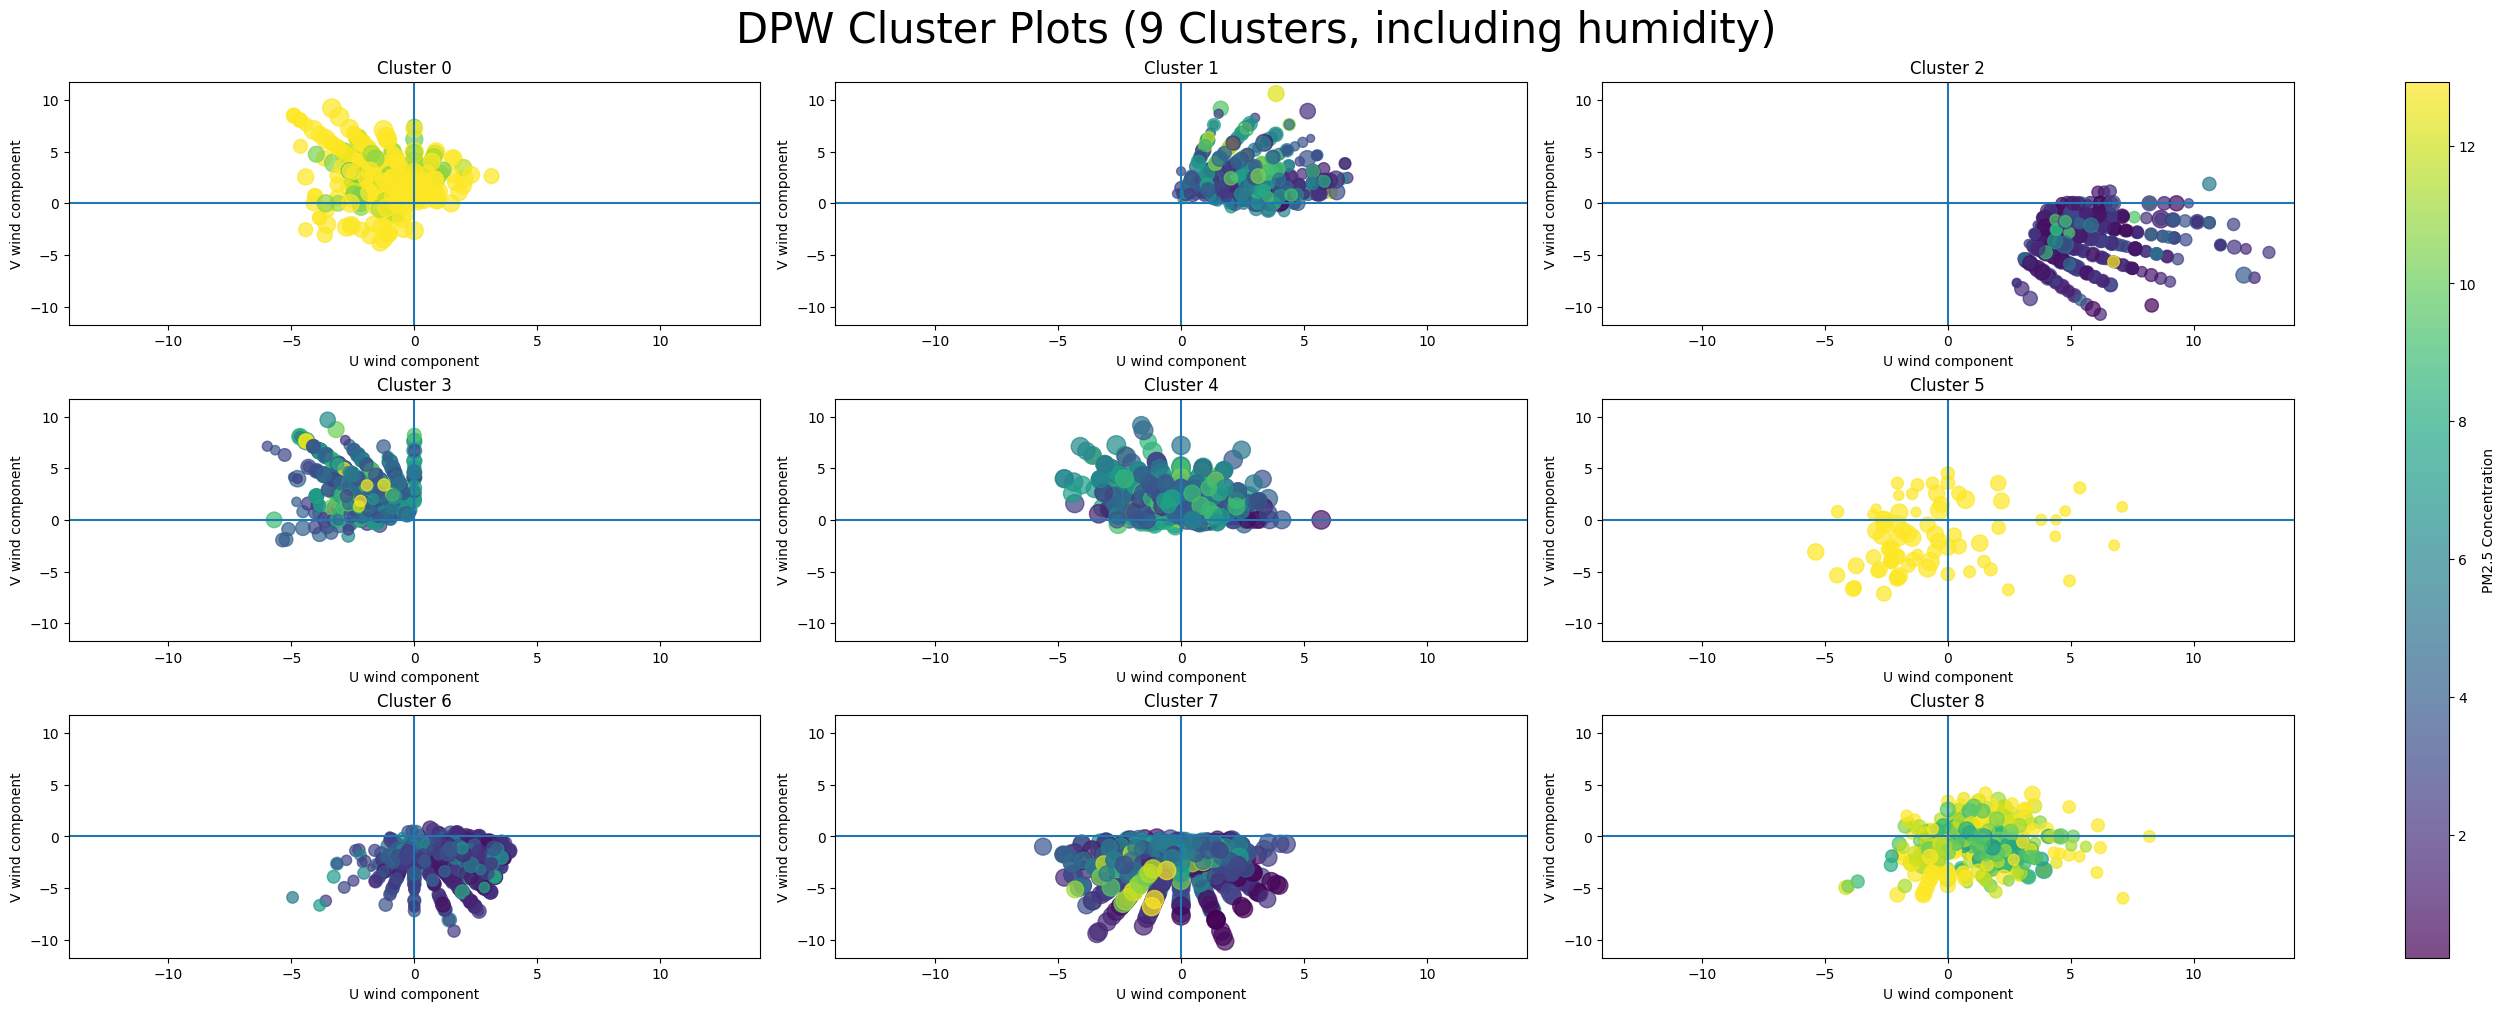

In [438]:
fig, axes = plt.subplots(3, 3, figsize=(25, 10), constrained_layout=True)
axes = axes.flatten()

#define shared color scale for comparison
#outliers make it hard to differentiate lower concentrations- utilize lower quantile
vmin = dpw_final["pm25"].min()
vmax = dpw_final["pm25"].quantile(0.9)

#bounds that will be used for all plots
u_abs = max(abs(dpw_final["wind_u"].min()), abs(dpw_final["wind_u"].max()))
v_abs = max(abs(dpw_final["wind_v"].min()), abs(dpw_final["wind_v"].max()))


clusters = sorted(dpw_final["cluster"].unique())
for i, c in enumerate(clusters):
    df_c = dpw_final[dpw_final["cluster"] == c]
    
    #scale humidity by 2 to make differences more visible
    sc = axes[i].scatter(df_c["wind_u"], df_c["wind_v"], c=df_c["pm25"], s=2*df_c["rh"], vmin=vmin, vmax=vmax, alpha=0.7)
    
    title_string = "Cluster " + str(c)
    axes[i].set_title(title_string)
    axes[i].set_xlabel("U wind component")
    axes[i].set_ylabel("V wind component")
    
    #set axis limits
    axes[i].set_xlim(-u_abs - 1, u_abs + 1)
    axes[i].set_ylim(-v_abs - 1, v_abs + 1)
    
    #draw axis lines
    axes[i].axhline(0)
    axes[i].axvline(0)

fig.colorbar(sc, ax=axes, label="PM2.5 Concentration")
fig.suptitle("DPW Cluster Plots (9 Clusters, including humidity)", fontsize=30)
plt.show()

         count       mean        std        min        25%        50%        75%        max
cluster                                                                                    
0        452.0  70.378220  12.723838  30.405000  62.557500  71.500833  80.447917  92.126667
1        429.0  41.618162  11.658822  12.038333  33.395000  41.995000  50.241667  75.248333
2        564.0  40.478027  12.057616  11.888333  32.851667  39.617500  47.485000  78.851667
3        533.0  45.069093  12.162763  18.656667  35.723333  46.533333  54.901667  76.950000
4        962.0  77.102661   8.747637  55.568333  70.432917  78.195000  84.520417  92.488333
5         77.0  53.449610  17.228722  24.570000  38.525000  53.255000  68.738333  82.738333
6        834.0  41.766355  11.972127  12.101667  32.862083  42.969167  50.872083  68.780000
7        698.0  77.422717   9.179824  49.895000  70.542500  79.086667  85.350417  91.570000
8        389.0  49.754246  11.527489  27.811667  40.181667  50.358333  58.925000

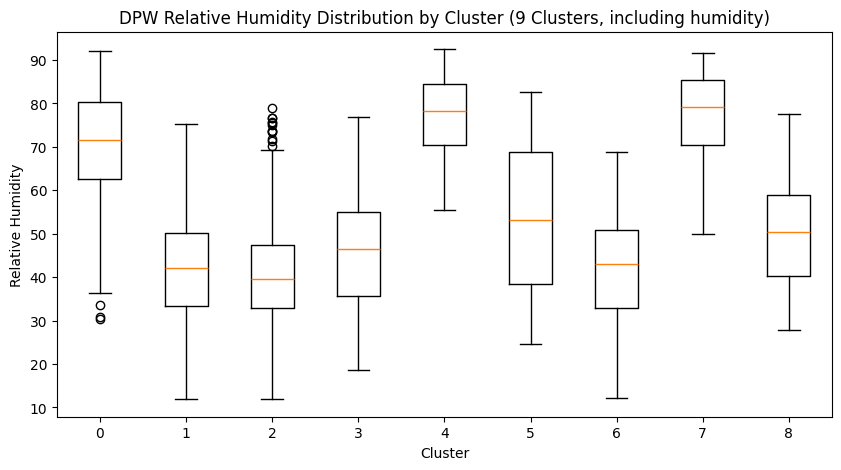

In [439]:
#print cluster statistics for wind speed
cluster_stats = dpw_final.groupby("cluster")["rh"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(dpw_final[dpw_final["cluster"] == c]["rh"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("DPW Relative Humidity Distribution by Cluster (9 Clusters, including humidity)")
plt.xlabel("Cluster")
plt.ylabel("Relative Humidity")

plt.show()

## PEMA Unsupervised

In [440]:
pema_final = pd.read_csv("final PM data/pema_final_pm25.csv")
pema_final.head()

,datetime_utc,rh,temp,wd,ws,pm25,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
0,2025-01-02 06:00:00+00:00,61.271667,3.978333,288.680000,4.513833,0.045150,4.276054,-1.445701,6,1.000000,6.123234e-17,0.040767,0.049150,0.033750,0.096833,0
1,2025-01-02 07:00:00+00:00,57.641667,3.725000,289.245000,5.204833,0.052300,4.913976,-1.715556,7,0.965926,-2.588190e-01,0.045150,0.040767,0.049150,0.050633,0
2,2025-01-02 08:00:00+00:00,53.136667,3.656667,294.898333,5.591833,0.052267,5.072107,-2.354215,8,0.866025,-5.000000e-01,0.052300,0.045150,0.040767,0.047417,0
3,2025-01-02 09:00:00+00:00,50.996667,3.491667,291.131667,4.624833,0.054683,4.313834,-1.667310,9,0.707107,-7.071068e-01,0.052267,0.052300,0.045150,0.033750,0
4,2025-01-02 10:00:00+00:00,50.645000,3.486667,284.775000,4.678333,0.061867,4.523643,-1.193087,10,0.500000,-8.660254e-01,0.054683,0.052267,0.052300,0.049150,0


In [441]:
#define features to be used in algorithm here
#initially we just use wind and PM 2.5 concentrations
X = pema_final[["pm25", "wind_u", "wind_v"]].values

#scale all features using Z score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#use five clusters to generally align with bins
kmeans = KMeans(n_clusters=5, random_state=8)
clusters = kmeans.fit_predict(X_scaled)

pema_final["cluster"] = clusters

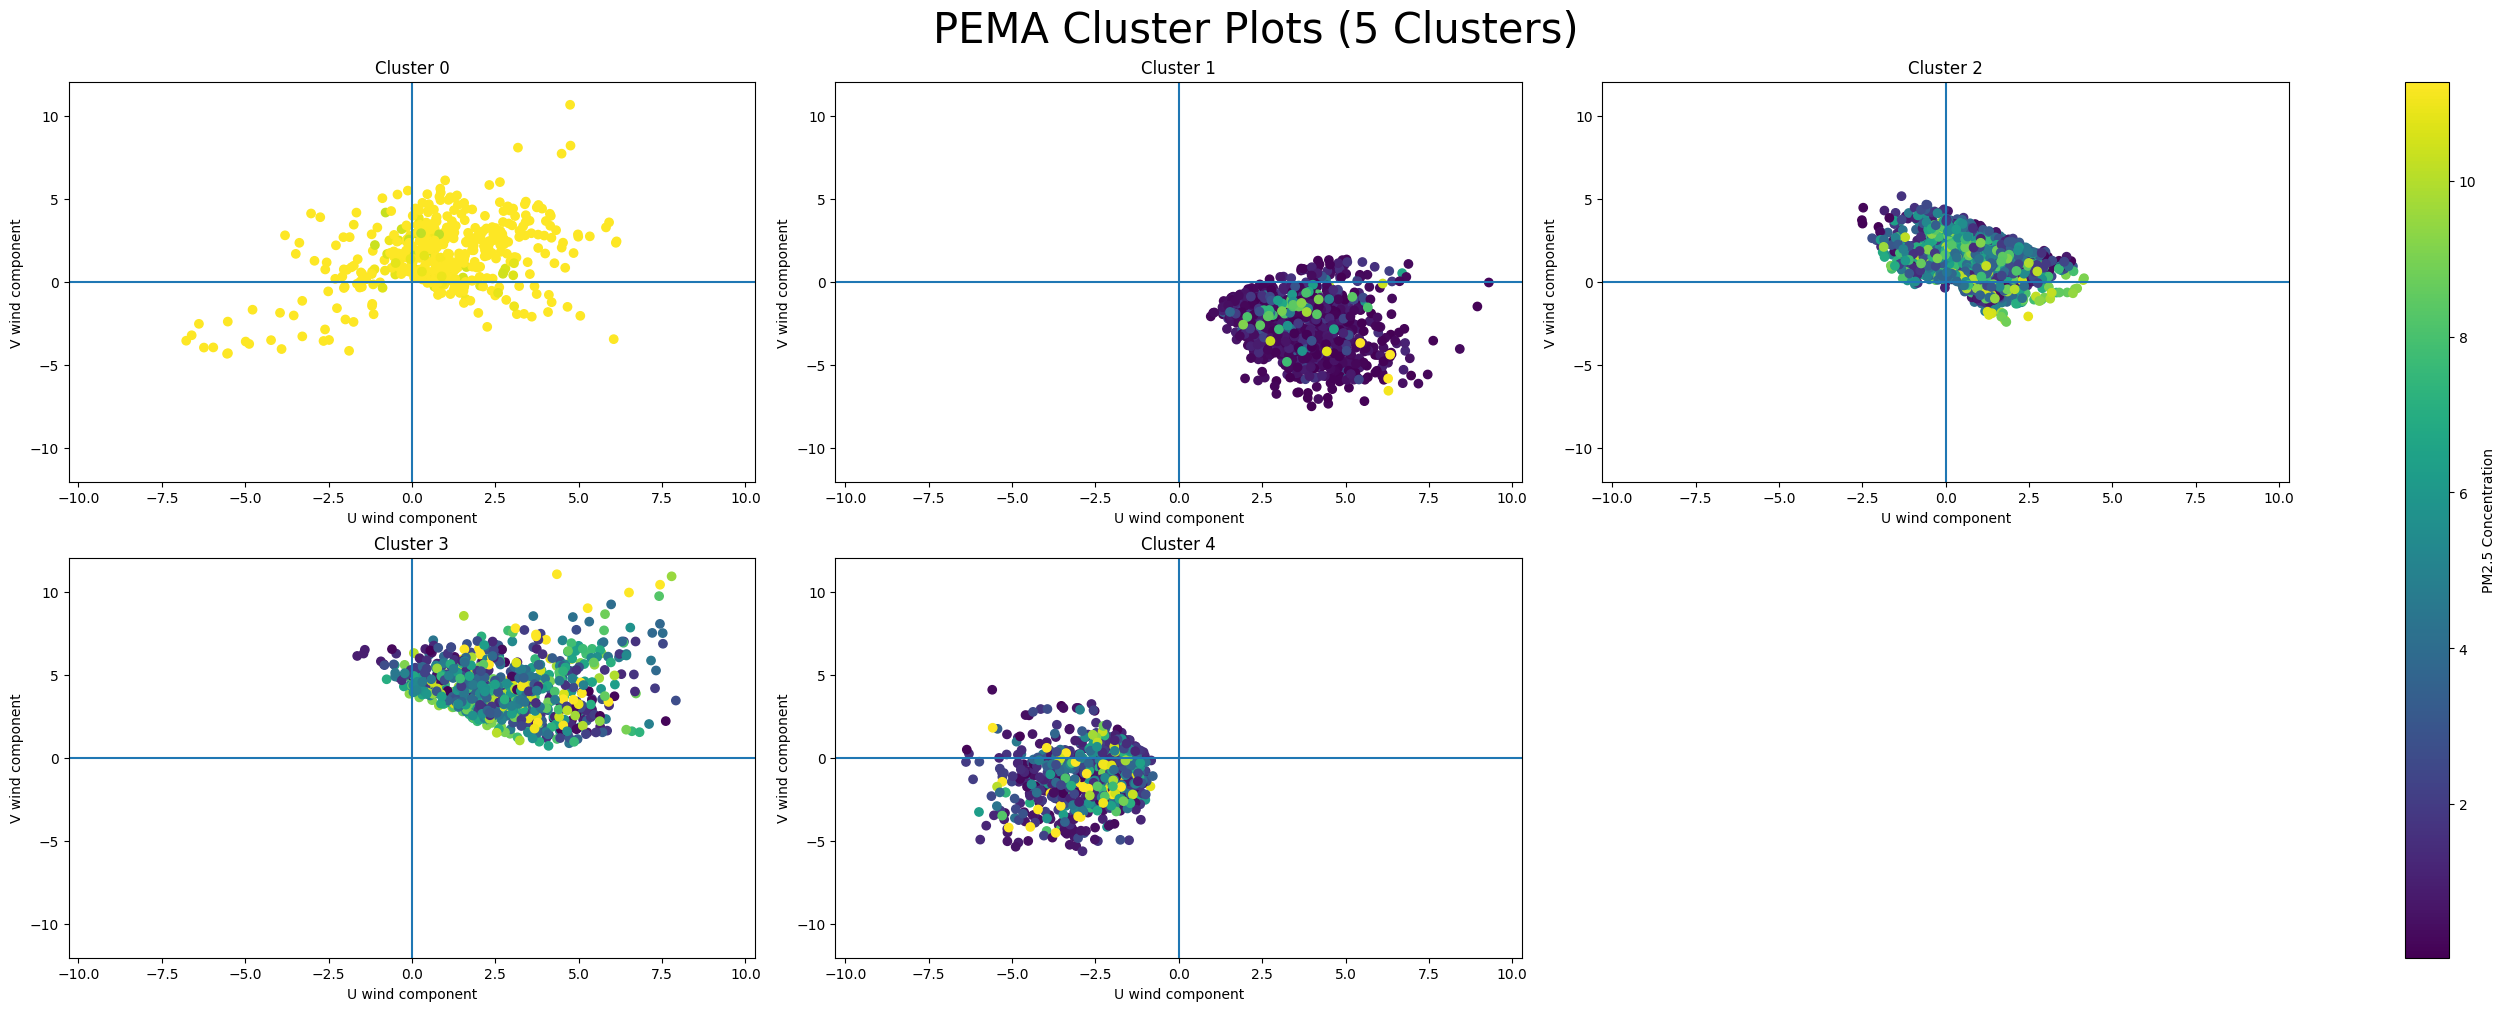

In [442]:
fig, axes = plt.subplots(2, 3, figsize=(25, 10), constrained_layout=True)
axes = axes.flatten()

#define shared color scale for comparison
#outliers make it hard to differentiate lower concentrations- utilize lower quantile
vmin = pema_final["pm25"].min()
vmax = pema_final["pm25"].quantile(0.9)

#bounds that will be used for all plots
u_abs = max(abs(pema_final["wind_u"].min()), abs(pema_final["wind_u"].max()))
v_abs = max(abs(pema_final["wind_v"].min()), abs(pema_final["wind_v"].max()))

clusters = sorted(pema_final["cluster"].unique())
for i, c in enumerate(clusters):
    df_c = pema_final[pema_final["cluster"] == c]
    
    sc = axes[i].scatter(df_c["wind_u"], df_c["wind_v"], c=df_c["pm25"], vmin=vmin, vmax=vmax)
    
    title_string = "Cluster " + str(c)
    axes[i].set_title(title_string)
    axes[i].set_xlabel("U wind component")
    axes[i].set_ylabel("V wind component")
    
    #set axis limits
    axes[i].set_xlim(-u_abs - 1, u_abs + 1)
    axes[i].set_ylim(-v_abs - 1, v_abs + 1)
    
    #draw axis lines
    axes[i].axhline(0)
    axes[i].axvline(0)

#remove extra plot
fig.delaxes(axes[-1])

fig.colorbar(sc, ax=axes, label="PM2.5 Concentration")
fig.suptitle("PEMA Cluster Plots (5 Clusters)", fontsize=30)
plt.show()

          count       mean       std        min        25%        50%        75%        max
cluster                                                                                    
0         446.0  16.547558  8.219971  10.135417  12.406817  14.681283  17.668408  91.840267
1        1066.0   1.105670  1.933293   0.030983   0.197425   0.386467   1.028325  14.653917
2        1370.0   4.185315  2.825491   0.075083   1.685654   3.833808   6.317908  10.844233
3         800.0   5.394048  3.333494   0.041833   2.648529   4.952033   7.832113  19.497017
4         733.0   3.258049  3.028349   0.079617   1.066867   2.095783   4.813217  15.147350


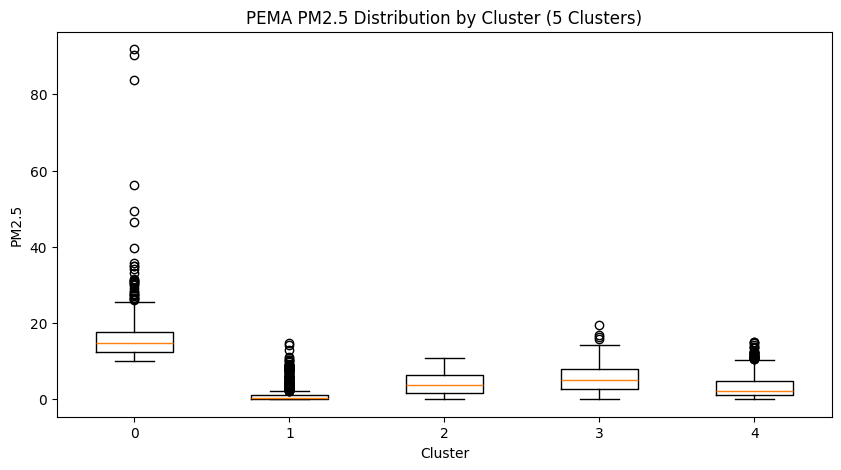

In [443]:
#print cluster statistics for PM2.5
cluster_stats = pema_final.groupby("cluster")["pm25"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(pema_final[pema_final["cluster"] == c]["pm25"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("PEMA PM2.5 Distribution by Cluster (5 Clusters)")
plt.xlabel("Cluster")
plt.ylabel("PM2.5")

plt.show()

          count      mean       std       min       25%       50%       75%        max
cluster                                                                               
0         446.0  3.034012  1.731541  0.282167  1.638250  2.914500  4.091333  11.693333
1        1066.0  4.715151  1.520019  1.765667  3.602583  4.652833  5.686292   9.442000
2        1370.0  1.931748  1.030991  0.000000  1.020042  1.872917  2.731917   5.346000
3         800.0  5.285935  1.619908  2.946500  4.080625  4.915750  6.072333  13.426833
4         733.0  3.340103  1.318185  0.844167  2.360833  3.098667  4.163167   7.737000


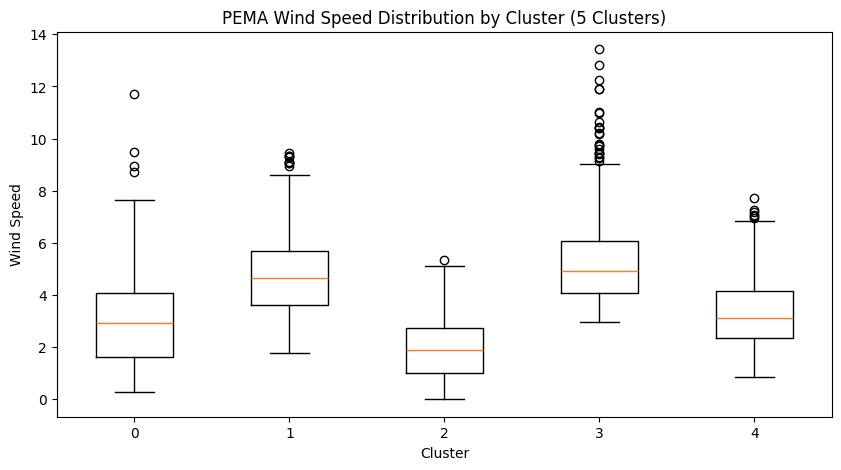

In [444]:
#print cluster statistics for wind speed
cluster_stats = pema_final.groupby("cluster")["ws"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(pema_final[pema_final["cluster"] == c]["ws"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("PEMA Wind Speed Distribution by Cluster (5 Clusters)")
plt.xlabel("Cluster")
plt.ylabel("Wind Speed")

plt.show()

In [445]:
# repeat experiment with 9 clusters

#define features to be used in algorithm here
#initially we just use wind and PM 2.5 concentrations
X = pema_final[["pm25", "wind_u", "wind_v"]].values

#scale all features using Z score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#use five clusters to generally align with bins
kmeans = KMeans(n_clusters=9, random_state=8)
clusters = kmeans.fit_predict(X_scaled)

pema_final["cluster"] = clusters

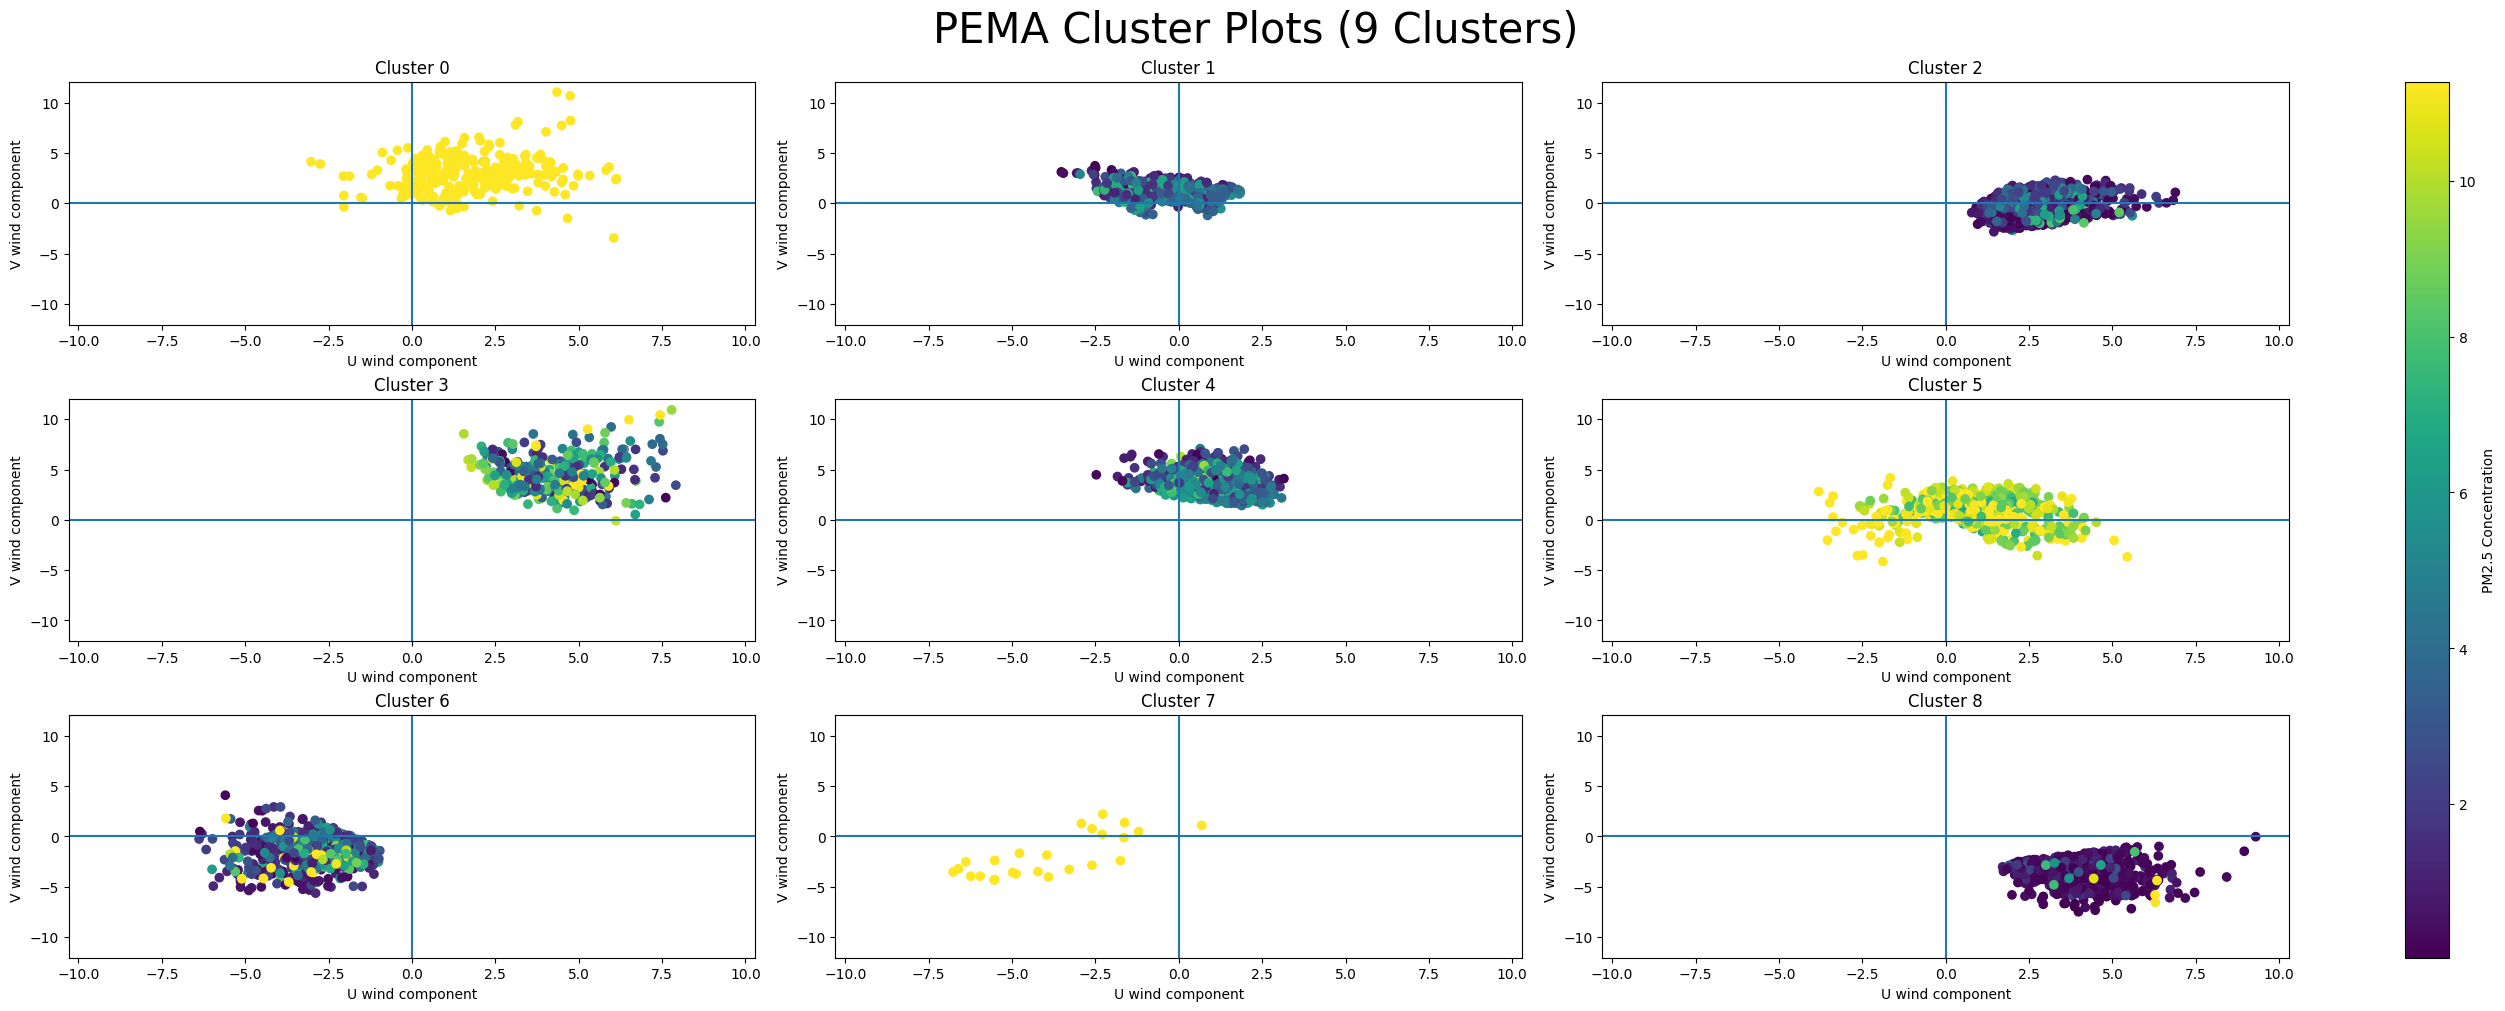

In [446]:
fig, axes = plt.subplots(3, 3, figsize=(25, 10), constrained_layout=True)
axes = axes.flatten()

#define shared color scale for comparison
#outliers make it hard to differentiate lower concentrations- utilize lower quantile
vmin = pema_final["pm25"].min()
vmax = pema_final["pm25"].quantile(0.9)

#bounds that will be used for all plots
u_abs = max(abs(pema_final["wind_u"].min()), abs(pema_final["wind_u"].max()))
v_abs = max(abs(pema_final["wind_v"].min()), abs(pema_final["wind_v"].max()))

clusters = sorted(pema_final["cluster"].unique())
for i, c in enumerate(clusters):
    df_c = pema_final[pema_final["cluster"] == c]
    
    sc = axes[i].scatter(df_c["wind_u"], df_c["wind_v"], c=df_c["pm25"], vmin=vmin, vmax=vmax)
    
    title_string = "Cluster " + str(c)
    axes[i].set_title(title_string)
    axes[i].set_xlabel("U wind component")
    axes[i].set_ylabel("V wind component")
    
    #set axis limits
    axes[i].set_xlim(-u_abs - 1, u_abs + 1)
    axes[i].set_ylim(-v_abs - 1, v_abs + 1)
    
    #draw axis lines
    axes[i].axhline(0)
    axes[i].axvline(0)


fig.colorbar(sc, ax=axes, label="PM2.5 Concentration")
fig.suptitle("PEMA Cluster Plots (9 Clusters)", fontsize=30)
plt.show()

         count       mean        std        min        25%        50%        75%        max
cluster                                                                                    
0        270.0  16.740574   3.614926  10.784000  14.359646  16.013583  18.450179  30.056467
1        646.0   3.157903   1.904654   0.075083   1.502800   2.939942   4.679067   7.910900
2        684.0   1.703846   1.881306   0.035317   0.319879   0.927483   2.328400   8.392767
3        341.0   5.855859   3.225523   0.041833   3.303183   5.738800   8.267067  16.999650
4        639.0   4.198464   2.440830   0.070933   2.054708   4.168650   5.925620  10.437783
5        524.0   9.932850   2.229491   5.697417   8.336216   9.612842  11.184971  22.422567
6        611.0   3.069862   2.848459   0.087033   0.993450   2.037233   4.546375  15.147350
7         25.0  40.206799  19.769491  23.141967  30.159200  31.693917  39.588717  91.840267
8        675.0   0.748738   1.340608   0.030983   0.185183   0.344100   0.811975

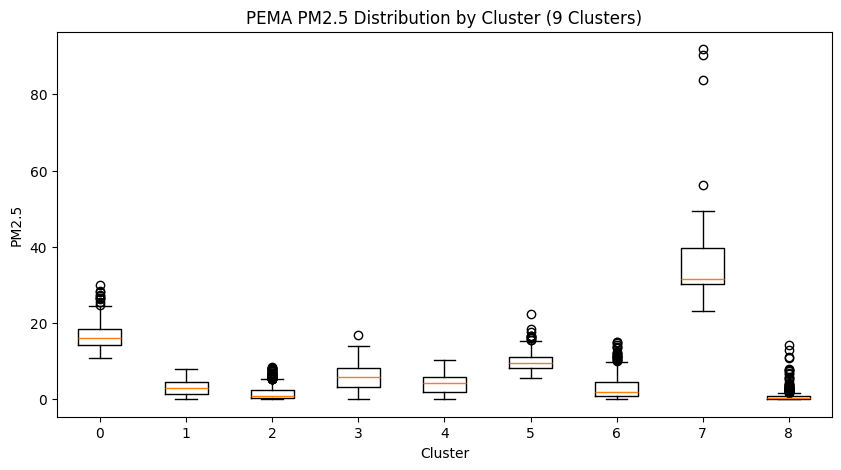

In [447]:
#print cluster statistics for PM2.5
cluster_stats = pema_final.groupby("cluster")["pm25"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(pema_final[pema_final["cluster"] == c]["pm25"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("PEMA PM2.5 Distribution by Cluster (9 Clusters)")
plt.xlabel("Cluster")
plt.ylabel("PM2.5")

plt.show()

         count      mean       std       min       25%       50%       75%        max
cluster                                                                              
0        270.0  3.748394  1.792346  0.464000  2.464417  3.539583  4.827500  11.886167
1        646.0  1.356546  0.825291  0.000000  0.717125  1.184917  1.830299   4.709167
2        684.0  2.976813  1.101213  1.000333  2.151958  2.858000  3.632792   6.971333
3        341.0  6.389022  1.638795  3.815333  5.138333  6.050667  7.186167  13.426833
4        639.0  3.899695  1.046642  2.070000  3.082583  3.755667  4.472250   7.304833
5        524.0  2.117177  1.088489  0.217833  1.250417  2.056250  2.920375   6.567167
6        611.0  3.594467  1.250152  1.541333  2.657833  3.366833  4.391833   7.737000
7         25.0  4.738493  2.129126  1.291667  2.974833  5.061667  6.865833   7.637000
8        675.0  5.457598  1.248811  3.312167  4.553583  5.220667  6.177583   9.442000


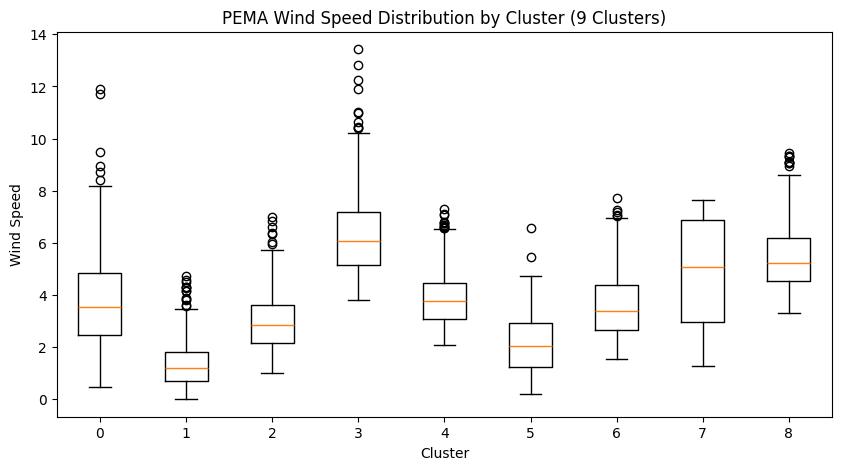

In [448]:
#print cluster statistics for wind speed
cluster_stats = pema_final.groupby("cluster")["ws"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(pema_final[pema_final["cluster"] == c]["ws"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("PEMA Wind Speed Distribution by Cluster (9 Clusters)")
plt.xlabel("Cluster")
plt.ylabel("Wind Speed")

plt.show()

In [449]:
#repeat experiment with 5 clusters, but now including humidity

#define features to be used in algorithm here
#initially we just use wind and PM 2.5 concentrations
X = pema_final[["pm25", "wind_u", "wind_v", "rh"]].values

#scale all features using Z score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#use five clusters to generally align with bins
kmeans = KMeans(n_clusters=9, random_state=8)
clusters = kmeans.fit_predict(X_scaled)

pema_final["cluster"] = clusters

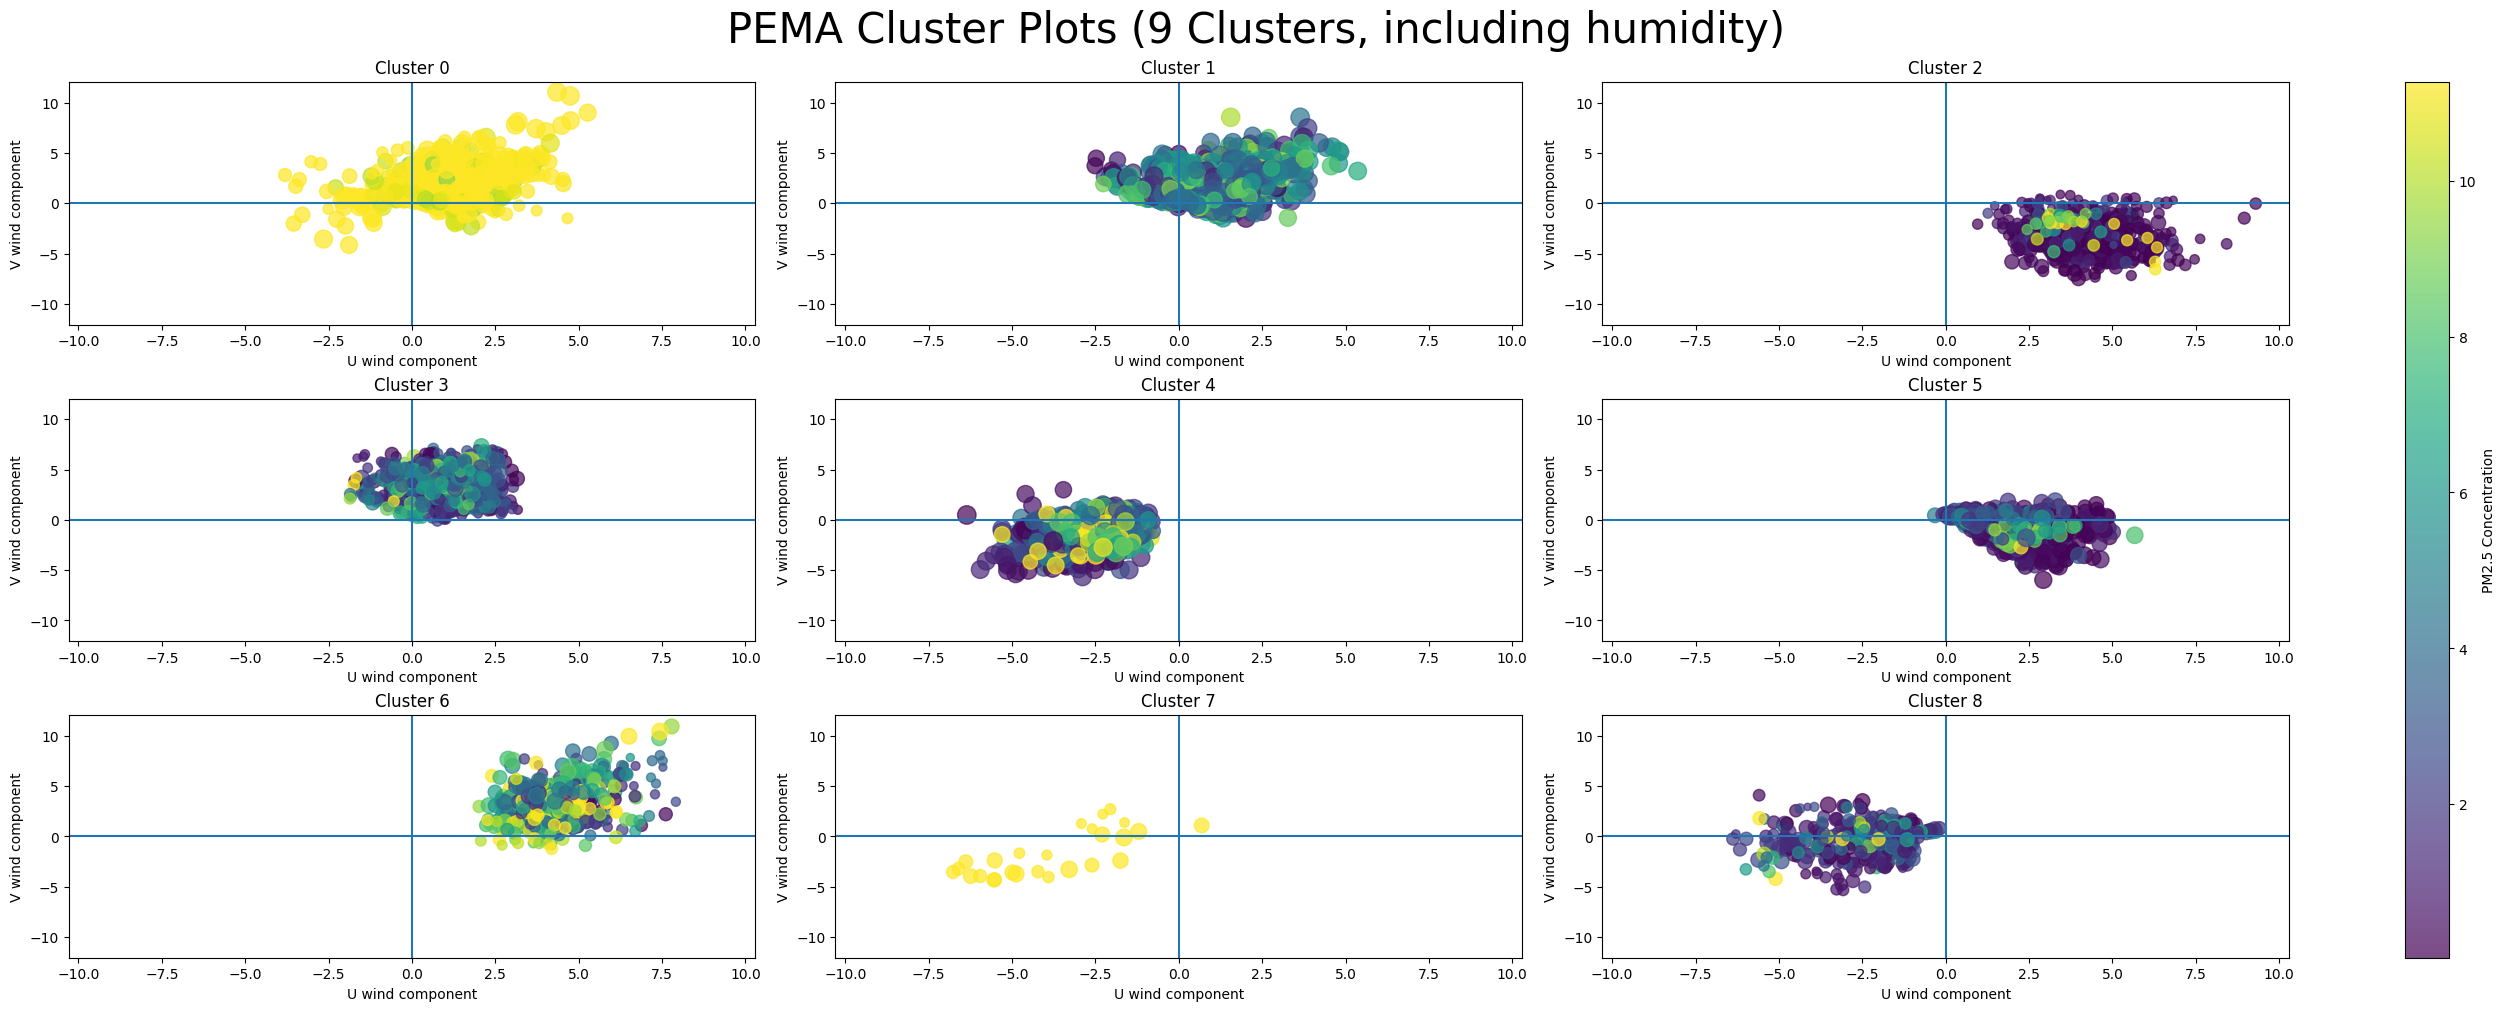

In [450]:
fig, axes = plt.subplots(3, 3, figsize=(25, 10), constrained_layout=True)
axes = axes.flatten()

#define shared color scale for comparison
#outliers make it hard to differentiate lower concentrations- utilize lower quantile
vmin = pema_final["pm25"].min()
vmax = pema_final["pm25"].quantile(0.9)

#bounds that will be used for all plots
u_abs = max(abs(pema_final["wind_u"].min()), abs(pema_final["wind_u"].max()))
v_abs = max(abs(pema_final["wind_v"].min()), abs(pema_final["wind_v"].max()))


clusters = sorted(pema_final["cluster"].unique())
for i, c in enumerate(clusters):
    df_c = pema_final[pema_final["cluster"] == c]
    
    #scale humidity by 2 to make differences more visible
    sc = axes[i].scatter(df_c["wind_u"], df_c["wind_v"], c=df_c["pm25"], s=2*df_c["rh"], vmin=vmin, vmax=vmax, alpha=0.7)
    
    title_string = "Cluster " + str(c)
    axes[i].set_title(title_string)
    axes[i].set_xlabel("U wind component")
    axes[i].set_ylabel("V wind component")
    
    #set axis limits
    axes[i].set_xlim(-u_abs - 1, u_abs + 1)
    axes[i].set_ylim(-v_abs - 1, v_abs + 1)
    
    #draw axis lines
    axes[i].axhline(0)
    axes[i].axvline(0)

fig.colorbar(sc, ax=axes, label="PM2.5 Concentration")
fig.suptitle("PEMA Cluster Plots (9 Clusters, including humidity)", fontsize=30)
plt.show()

         count       mean        std        min        25%        50%        75%        max
cluster                                                                                    
0        456.0  66.550786  14.990836  22.260714  57.181250  68.520000  78.203333  92.378333
1        934.0  78.305189   8.745219  55.208333  72.161667  79.736667  85.600833  94.206667
2        685.0  34.005481   9.743428  11.440000  27.581667  33.885000  40.736667  62.723333
3        489.0  39.158528  12.191926  11.691667  29.215000  39.818333  49.331667  64.343333
4        484.0  79.080191   8.616163  53.667857  72.242083  82.194167  85.824167  90.863333
5        668.0  54.273305  10.647130  28.656667  47.350833  53.659167  60.582917  88.501667
6        376.0  40.130302  13.006863  14.636667  30.284167  39.075000  48.790833  78.770000
7         26.0  45.971308  15.262798  24.310000  30.971667  46.975833  57.882917  71.236667
8        297.0  41.272882  12.058793  11.123333  31.746667  41.738333  51.583333

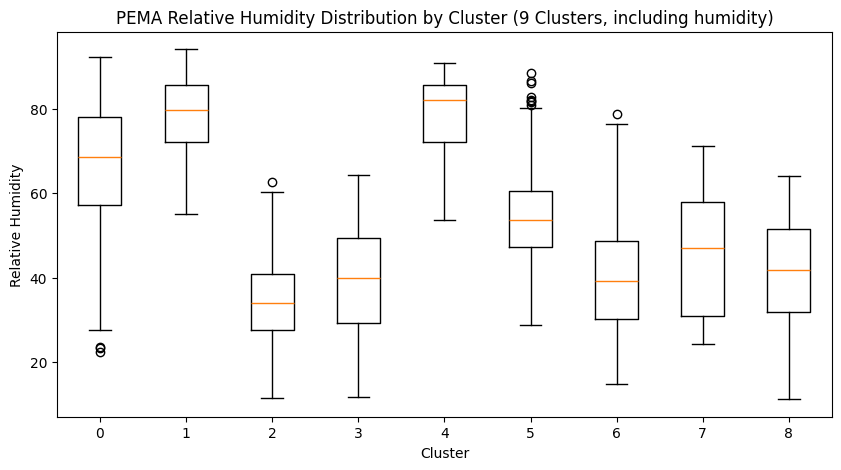

In [451]:
#print cluster statistics for wind speed
cluster_stats = pema_final.groupby("cluster")["rh"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(pema_final[pema_final["cluster"] == c]["rh"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("PEMA Relative Humidity Distribution by Cluster (9 Clusters, including humidity)")
plt.xlabel("Cluster")
plt.ylabel("Relative Humidity")

plt.show()

## PHA Unsupervised

In [452]:
pha_final = pd.read_csv("final PM data/pha_final_pm25.csv")
pha_final.head()

,datetime_utc,rh,temp,wd,ws,pm25,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
0,2025-01-02 06:00:00+00:00,62.023333,3.330000,261.698333,2.648500,0.207967,2.620748,0.382404,6,1.000000,6.123234e-17,0.165667,0.168467,0.198267,0.389583,0
1,2025-01-02 07:00:00+00:00,58.768333,3.020000,270.975000,2.878667,0.295167,2.878250,-0.048984,7,0.965926,-2.588190e-01,0.207967,0.165667,0.168467,0.214200,0
2,2025-01-02 08:00:00+00:00,55.421667,2.898333,273.275000,2.903833,0.309267,2.899091,-0.165891,8,0.866025,-5.000000e-01,0.295167,0.207967,0.165667,0.192533,0
3,2025-01-02 09:00:00+00:00,53.240000,2.845000,273.426667,2.866000,0.312800,2.860876,-0.171304,9,0.707107,-7.071068e-01,0.309267,0.295167,0.207967,0.198267,0
4,2025-01-02 10:00:00+00:00,52.566667,2.850000,266.546667,2.758667,0.346200,2.753657,0.166170,10,0.500000,-8.660254e-01,0.312800,0.309267,0.295167,0.168467,0


In [453]:
#define features to be used in algorithm here
#initially we just use wind and PM 2.5 concentrations
X = pha_final[["pm25", "wind_u", "wind_v"]].values

#scale all features using Z score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#use five clusters to generally align with bins
#decdided to shift the random seed here, since 8 caused a strange clustering
#i.e., one of the clusters had only three points!
kmeans = KMeans(n_clusters=5, random_state=9)
clusters = kmeans.fit_predict(X_scaled)

pha_final["cluster"] = clusters

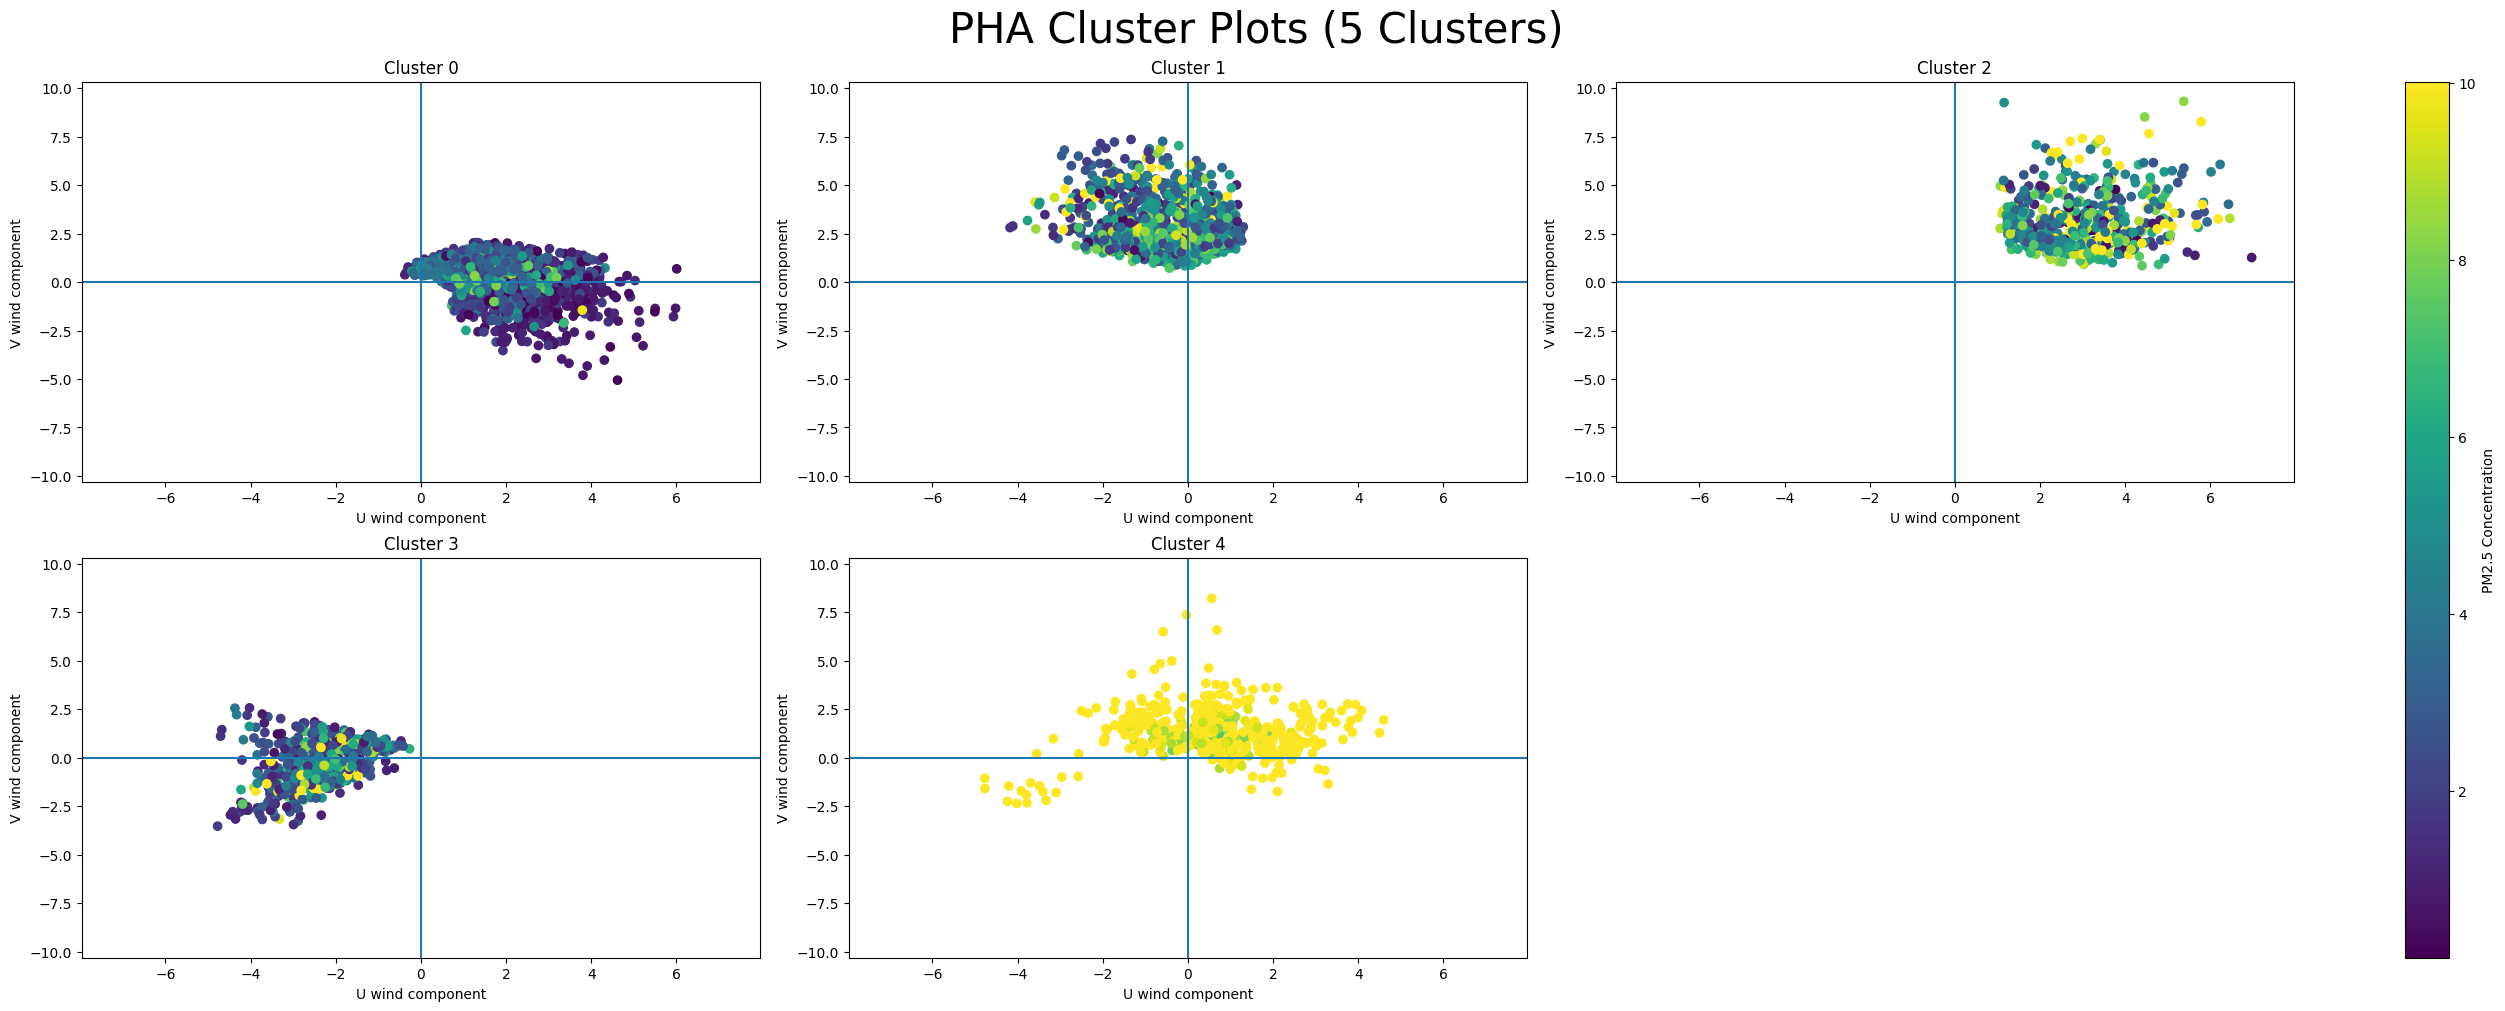

In [454]:
fig, axes = plt.subplots(2, 3, figsize=(25, 10), constrained_layout=True)
axes = axes.flatten()

#define shared color scale for comparison
#outliers make it hard to differentiate lower concentrations- utilize lower quantile
vmin = pha_final["pm25"].min()
vmax = pha_final["pm25"].quantile(0.9)

#bounds that will be used for all plots
u_abs = max(abs(pha_final["wind_u"].min()), abs(pha_final["wind_u"].max()))
v_abs = max(abs(pha_final["wind_v"].min()), abs(pha_final["wind_v"].max()))

clusters = sorted(pha_final["cluster"].unique())
for i, c in enumerate(clusters):
    df_c = pha_final[pha_final["cluster"] == c]
    
    sc = axes[i].scatter(df_c["wind_u"], df_c["wind_v"], c=df_c["pm25"], vmin=vmin, vmax=vmax)
    
    title_string = "Cluster " + str(c)
    axes[i].set_title(title_string)
    axes[i].set_xlabel("U wind component")
    axes[i].set_ylabel("V wind component")
    
    #set axis limits
    axes[i].set_xlim(-u_abs - 1, u_abs + 1)
    axes[i].set_ylim(-v_abs - 1, v_abs + 1)
    
    #draw axis lines
    axes[i].axhline(0)
    axes[i].axvline(0)

#remove extra plot
fig.delaxes(axes[-1])

fig.colorbar(sc, ax=axes, label="PM2.5 Concentration")
fig.suptitle("PHA Cluster Plots (5 Clusters)", fontsize=30)
plt.show()

          count       mean       std       min       25%        50%        75%         max
cluster                                                                                   
0        2046.0   2.469185  1.906064  0.119367  0.996400   1.820683   3.399188    9.790783
1         830.0   4.761003  2.683243  0.173867  2.591021   4.495108   6.618871   13.963400
2         530.0   5.712429  3.477756  0.185150  3.244792   5.186025   7.699521   19.334583
3         502.0   3.644417  2.595908  0.326717  1.756729   2.736667   4.889637   13.922800
4         493.0  13.692629  9.233695  7.184867  9.806200  11.649783  14.461933  128.021000


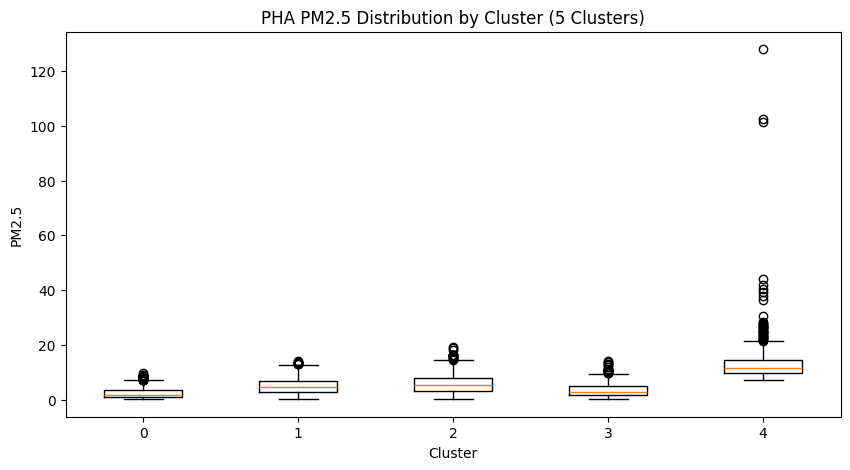

In [455]:
#print cluster statistics for PM2.5
cluster_stats = pha_final.groupby("cluster")["pm25"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(pha_final[pha_final["cluster"] == c]["pm25"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("PHA PM2.5 Distribution by Cluster (5 Clusters)")
plt.xlabel("Cluster")
plt.ylabel("PM2.5")

plt.show()

          count      mean       std       min       25%       50%       75%        max
cluster                                                                               
0        2046.0  2.081609  1.012255  0.320500  1.262708  1.969833  2.730000   6.848500
1         830.0  3.211929  1.393526  0.835833  2.118958  2.928417  4.108917   7.471333
2         530.0  4.472330  1.437266  2.143500  3.322250  4.178750  5.237625  10.753167
3         502.0  2.667556  0.988265  0.527833  1.955917  2.566833  3.258375   5.938500
4         493.0  2.069992  1.158279  0.432333  1.119833  1.932500  2.654167   8.232333


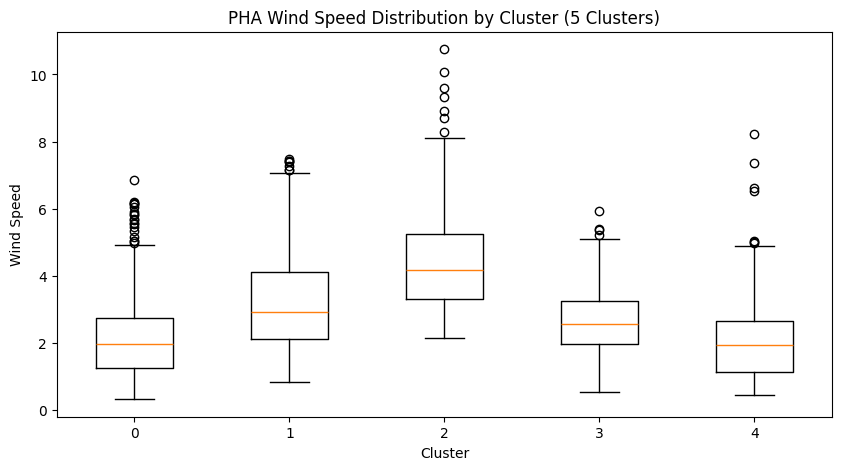

In [456]:
#print cluster statistics for wind speed
cluster_stats = pha_final.groupby("cluster")["ws"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(pha_final[pha_final["cluster"] == c]["ws"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("PHA Wind Speed Distribution by Cluster (5 Clusters)")
plt.xlabel("Cluster")
plt.ylabel("Wind Speed")

plt.show()

In [457]:
# repeat experiment with 9 clusters

#define features to be used in algorithm here
#initially we just use wind and PM 2.5 concentrations
X = pha_final[["pm25", "wind_u", "wind_v"]].values

#scale all features using Z score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#use five clusters to generally align with bins
kmeans = KMeans(n_clusters=9, random_state=8)
clusters = kmeans.fit_predict(X_scaled)

pha_final["cluster"] = clusters

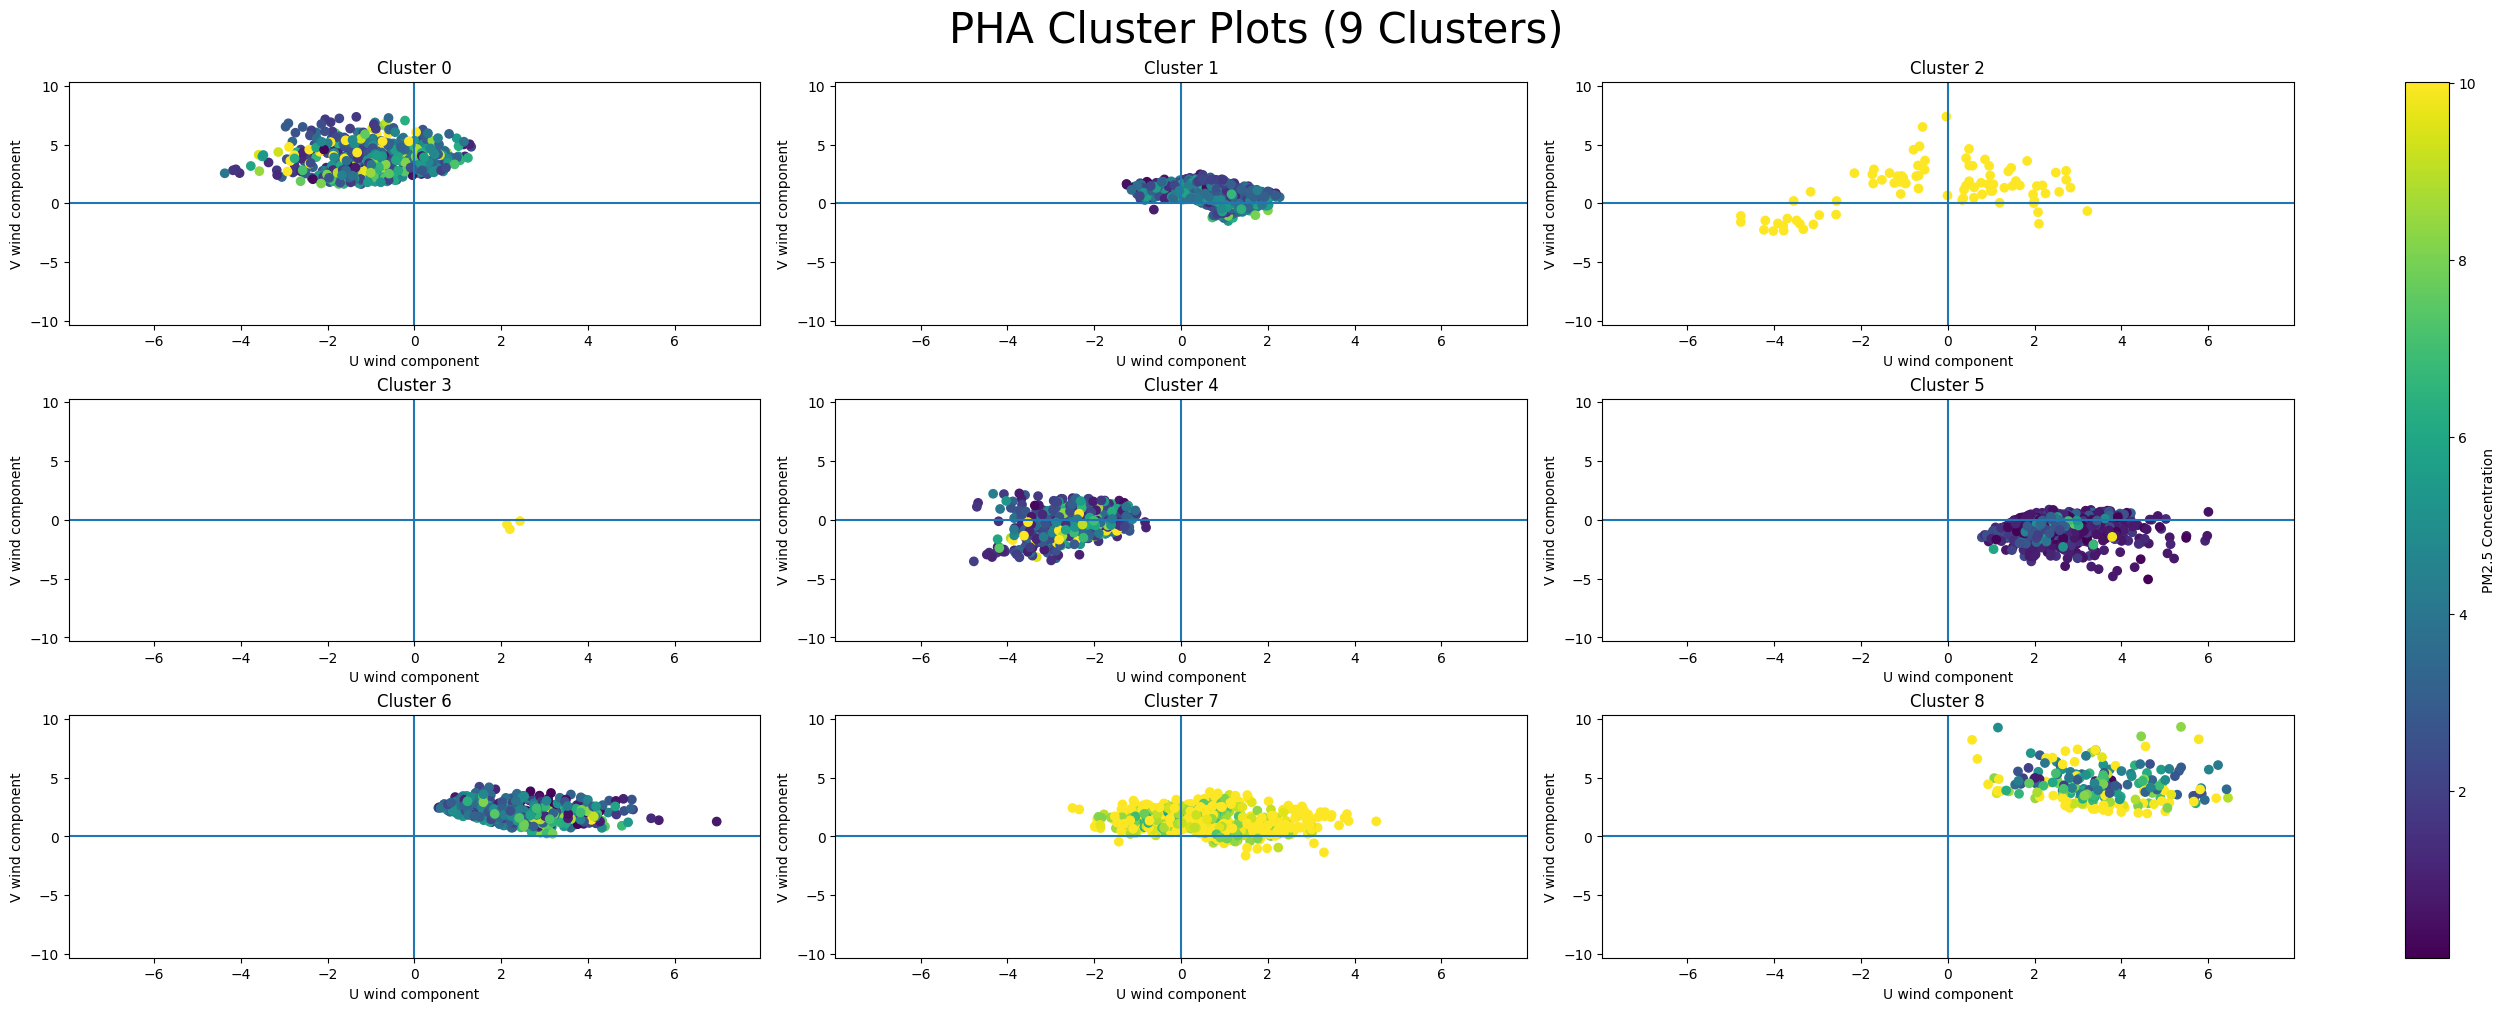

In [458]:
fig, axes = plt.subplots(3, 3, figsize=(25, 10), constrained_layout=True)
axes = axes.flatten()

#define shared color scale for comparison
#outliers make it hard to differentiate lower concentrations- utilize lower quantile
vmin = pha_final["pm25"].min()
vmax = pha_final["pm25"].quantile(0.9)

#bounds that will be used for all plots
u_abs = max(abs(pha_final["wind_u"].min()), abs(pha_final["wind_u"].max()))
v_abs = max(abs(pha_final["wind_v"].min()), abs(pha_final["wind_v"].max()))

clusters = sorted(pha_final["cluster"].unique())
for i, c in enumerate(clusters):
    df_c = pha_final[pha_final["cluster"] == c]
    
    sc = axes[i].scatter(df_c["wind_u"], df_c["wind_v"], c=df_c["pm25"], vmin=vmin, vmax=vmax)
    
    title_string = "Cluster " + str(c)
    axes[i].set_title(title_string)
    axes[i].set_xlabel("U wind component")
    axes[i].set_ylabel("V wind component")
    
    #set axis limits
    axes[i].set_xlim(-u_abs - 1, u_abs + 1)
    axes[i].set_ylim(-v_abs - 1, v_abs + 1)
    
    #draw axis lines
    axes[i].axhline(0)
    axes[i].axvline(0)


fig.colorbar(sc, ax=axes, label="PM2.5 Concentration")
fig.suptitle("PHA Cluster Plots (9 Clusters)", fontsize=30)
plt.show()

          count        mean        std         min         25%         50%         75%         max
cluster                                                                                           
0         529.0    4.652343   2.842679    0.173867    2.541200    4.106700    6.280300   14.729283
1        1043.0    3.274485   1.679254    0.203133    1.883433    3.051167    4.509700    8.144000
2          89.0   21.560947   6.190914   14.461933   17.597617   19.123783   24.114017   43.976950
3           3.0  110.622056  15.079672  101.327550  101.922583  102.517617  115.269308  128.021000
4         481.0    3.584221   2.559546    0.326717    1.751300    2.675583    4.884100   13.922800
5         972.0    1.409289   1.161116    0.119367    0.753763    1.049892    1.711063    9.790783
6         493.0    3.869922   2.274116    0.184767    2.117567    3.614033    5.408200   10.704267
7         584.0   10.015933   2.323611    5.805417    8.231346    9.631050   11.523625   16.719267
8         

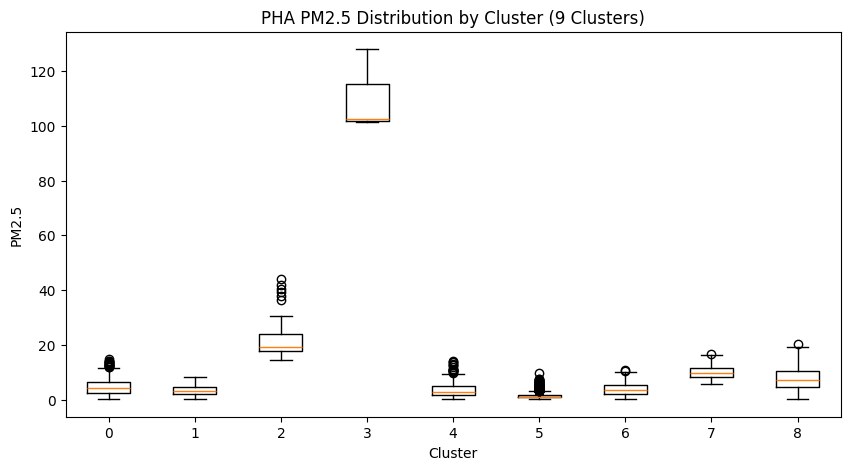

In [459]:
#print cluster statistics for PM2.5
cluster_stats = pha_final.groupby("cluster")["pm25"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(pha_final[pha_final["cluster"] == c]["pm25"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("PHA PM2.5 Distribution by Cluster (9 Clusters)")
plt.xlabel("Cluster")
plt.ylabel("PM2.5")

plt.show()

          count      mean       std       min       25%       50%       75%        max
cluster                                                                               
0         529.0  3.941994  1.222768  1.947833  2.942333  3.729833  4.804000   7.471333
1        1043.0  1.273806  0.436588  0.320500  0.953833  1.246333  1.570417   2.506167
2          89.0  2.882619  1.246054  0.438667  2.102000  2.661500  3.607667   7.373167
3           3.0  2.315889  0.135183  2.170333  2.255083  2.339833  2.388667   2.437500
4         481.0  2.751067  0.914805  0.850833  2.075000  2.648333  3.275000   5.938500
5         972.0  2.780101  0.823470  1.271667  2.205250  2.648667  3.214500   6.848500
6         493.0  3.376811  0.800153  2.044667  2.754333  3.229333  3.900667   7.081667
7         584.0  1.863102  0.835385  0.432333  1.157125  1.829833  2.421292   4.676667
8         207.0  5.792712  1.281801  3.711333  4.830167  5.673333  6.628083  10.753167


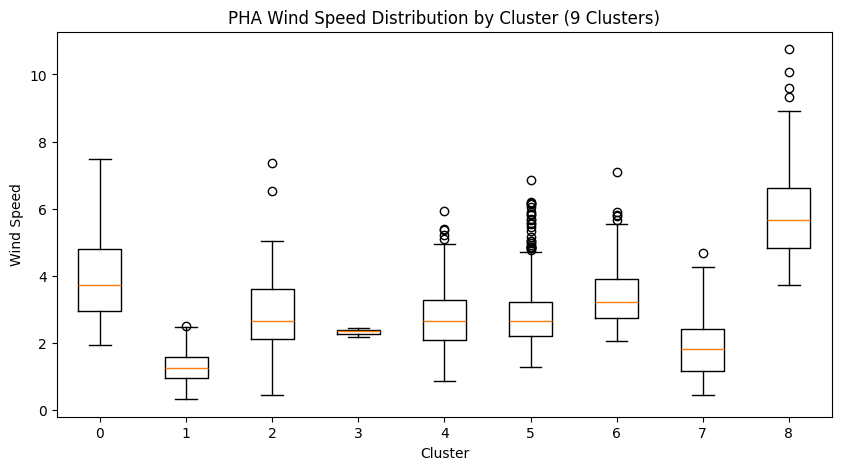

In [460]:
#print cluster statistics for wind speed
cluster_stats = pha_final.groupby("cluster")["ws"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(pha_final[pha_final["cluster"] == c]["ws"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("PHA Wind Speed Distribution by Cluster (9 Clusters)")
plt.xlabel("Cluster")
plt.ylabel("Wind Speed")

plt.show()

In [461]:
#repeat experiment with 5 clusters, but now including humidity

#define features to be used in algorithm here
#initially we just use wind and PM 2.5 concentrations
X = pha_final[["pm25", "wind_u", "wind_v", "rh"]].values

#scale all features using Z score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#use five clusters to generally align with bins
kmeans = KMeans(n_clusters=9, random_state=8)
clusters = kmeans.fit_predict(X_scaled)

pha_final["cluster"] = clusters

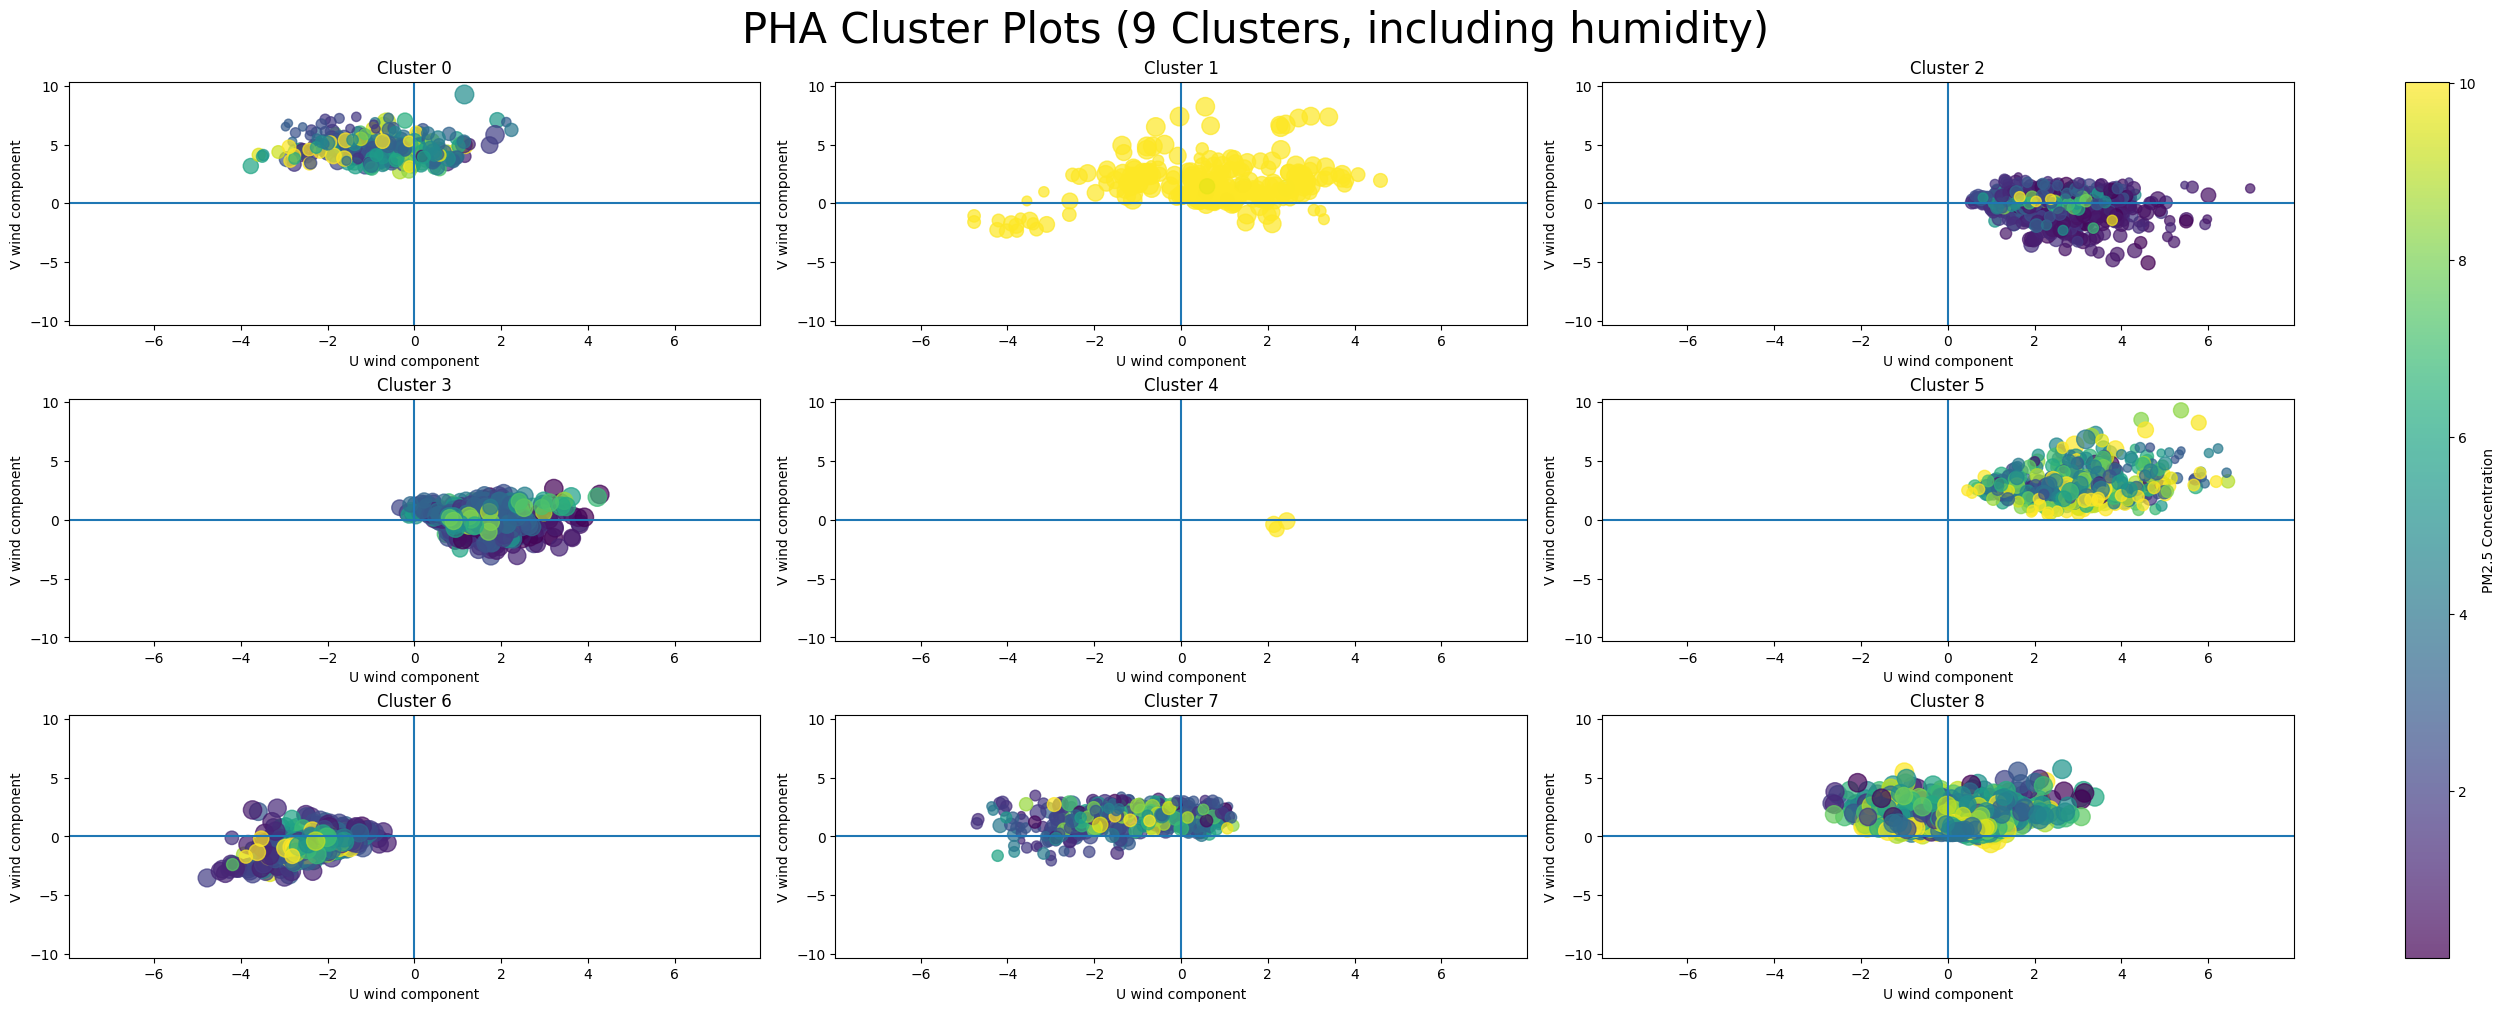

In [462]:
fig, axes = plt.subplots(3, 3, figsize=(25, 10), constrained_layout=True)
axes = axes.flatten()

#define shared color scale for comparison
#outliers make it hard to differentiate lower concentrations- utilize lower quantile
vmin = pha_final["pm25"].min()
vmax = pha_final["pm25"].quantile(0.9)

#bounds that will be used for all plots
u_abs = max(abs(pha_final["wind_u"].min()), abs(pha_final["wind_u"].max()))
v_abs = max(abs(pha_final["wind_v"].min()), abs(pha_final["wind_v"].max()))


clusters = sorted(pha_final["cluster"].unique())
for i, c in enumerate(clusters):
    df_c = pha_final[pha_final["cluster"] == c]
    
    #scale humidity by 2 to make differences more visible
    sc = axes[i].scatter(df_c["wind_u"], df_c["wind_v"], c=df_c["pm25"], s=2*df_c["rh"], vmin=vmin, vmax=vmax, alpha=0.7)
    
    title_string = "Cluster " + str(c)
    axes[i].set_title(title_string)
    axes[i].set_xlabel("U wind component")
    axes[i].set_ylabel("V wind component")
    
    #set axis limits
    axes[i].set_xlim(-u_abs - 1, u_abs + 1)
    axes[i].set_ylim(-v_abs - 1, v_abs + 1)
    
    #draw axis lines
    axes[i].axhline(0)
    axes[i].axvline(0)

fig.colorbar(sc, ax=axes, label="PM2.5 Concentration")
fig.suptitle("PHA Cluster Plots (9 Clusters, including humidity)", fontsize=30)
plt.show()

          count       mean        std        min        25%        50%        75%        max
cluster                                                                                     
0         263.0  45.679911  16.845978  13.118333  33.420833  45.610000  57.395000  90.105000
1         284.0  64.557796  18.137835  21.961667  52.506667  67.612500  79.200833  91.911667
2        1062.0  36.124778  10.636710  10.908333  27.795000  36.356667  45.092917  59.758333
3         859.0  68.115957  11.577109  46.061667  58.416667  66.301667  77.877500  92.011667
4           3.0  64.407222   5.714979  58.100000  61.990000  65.880000  67.560833  69.241667
5         443.0  43.504840  14.834500  11.818333  32.728333  42.170000  53.157500  90.011667
6         353.0  78.821520  11.899717  37.885000  72.460000  83.633333  87.103333  92.446667
7         362.0  39.413204  11.809775  11.368333  30.341250  39.419167  48.197083  66.786667
8         772.0  81.544196   8.560192  56.455000  76.228750  83.702500

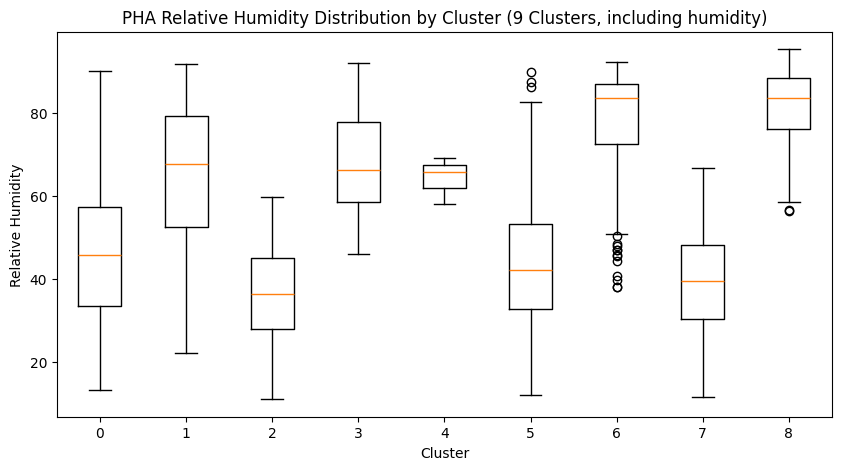

In [463]:
#print cluster statistics for wind speed
cluster_stats = pha_final.groupby("cluster")["rh"].describe()
print(cluster_stats.to_string())

#boxplots for each cluster
data = []
for c in clusters:
    data.append(pha_final[pha_final["cluster"] == c]["rh"].values)

plt.figure(figsize=(10,5))
plt.boxplot(data)

plt.xticks(range(1, len(clusters)+1), clusters)

plt.title("PHA Relative Humidity Distribution by Cluster (9 Clusters, including humidity)")
plt.xlabel("Cluster")
plt.ylabel("Relative Humidity")

plt.show()